# 🛰️ Satellite Analysis AI Agent — LangGraph Edition
**Powered by:** Google Earth Engine + Ollama (Local LLM) + LangGraph

### Architecture
```
START → ROUTER
          ├── surface vars  → SURFACE WORKER  ─────────────────┐
          ├── atmo vars     → ATMO WORKER     ─────────────────┤ → MERGE
          ├── lulc          → LULC WORKER     ─────────────────┘
          ├── question      → QA WORKER → END
          └── unknown       → UNKNOWN → END
                                  ↓
                           CONTEXT WORKER (web search)
                                  ↓
                           PRINT STATS
                                  ↓
                           INSIGHT GENERATOR (Ollama LLM)
                                  ↓
                           EVALUATOR (score 1-10)
                            ├── score ≥ 7 → FINAL OUTPUT → END
                            └── score < 7 → back to INSIGHT GENERATOR (max 3x)
```

### Available Variables
**Surface (Landsat 8):** `ndvi` `evi` `savi` `ndwi` `mndwi` `ndbi` `ui` `nbi` `bsi` `ndsi` `lst` `uhi` `rgb`

**Atmospheric (Sentinel-5P):** `co` `ch4` `no2` `so2` `aerosol` `o3` `gpp` `burned` `ffpi`

**Land Cover (Random Forest + ESA WorldCover):** `lulc` / `land cover` / `land use`

### How to use
1. Run **Cell 1** — authenticate GEE (if needed)
2. Run **Cell 2** — initialize GEE + Ollama config  
3. Run **Cell 3** — load all analysis functions
4. Run **Cell 4A** — register LangGraph tools
5. Run **Cell 4B** — compile LangGraph agent graph
6. Run **Cell 5** — start the chat loop

### Example prompts
```
Show NDVI in Jakarta from 2023-01-01 to 2023-12-31
Analyze NO2 and CO pollution in Beijing in 2022
LST and UHI in Cairo, summer 2021
Land cover in Bali from 2022-01-01 to 2022-12-31
Land cover in Hokkaido from 2022-04-01 to 2022-10-31
What does FFPI measure?
```

### Best regions for LULC
Islands and provinces work best: Bali, Hokkaido, Punjab, Dubai, Iceland


## Cell 1 — Install Dependencies

In [8]:
# import subprocess, sys
# packages = [
#     'earthengine-api', 'geemap', 'matplotlib', 'numpy', 'Pillow',
#     'requests', 'folium', 'branca', 'duckduckgo-search',
#     'langgraph', 'langchain-core', 'langchain-ollama', 'pydantic',
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
# print("All packages installed!")

In [9]:
# import ee
# ee.Authenticate()

## Cell 2 — Initialize GEE + Ollama Config

In [10]:
import ee
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import json
import os
import urllib.request
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display, Image, HTML

# ── GEE Config ────────────────────────────────────────────────────────────────
GEE_PROJECT = 'case-study-360616'   # ← change to your project ID
ee.Initialize(project=GEE_PROJECT)
print('✅ Google Earth Engine initialized.')

# ── Ollama Config ─────────────────────────────────────────────────────────────
OLLAMA_URL   = 'http://localhost:11434/api/chat'
OLLAMA_MODEL = 'gemma3:4b'   # ← change to your local model name
                               # e.g. 'llama3.2', 'mistral', 'qwen2.5:14b'

# ── Output folder ─────────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.expanduser('~/Downloads/satellite_agent_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'✅ Output folder: {OUTPUT_DIR}')

# ── Test Ollama connection ────────────────────────────────────────────────────
try:
    r = requests.get('http://localhost:11434/api/tags', timeout=3)
    models = [m['name'] for m in r.json().get('models', [])]
    print(f'✅ Ollama connected  |  Available models: {models}')
except Exception as e:
    print(f'⚠️  Ollama not reachable: {e}')
    print('   Make sure Ollama is running: ollama serve')

✅ Google Earth Engine initialized.
✅ Output folder: /Users/rafiqnaufalkastara/Downloads/satellite_agent_outputs
✅ Ollama connected  |  Available models: ['qwen3.5:9b', 'mistral:latest', 'llama3.1:8b', 'gemma3:4b']


## Cell 3 — Load All Analysis Functions

In [11]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import textwrap
import time

# =============================================================================
# SECTION A - GEE PREPROCESSING
# =============================================================================

def apply_scaling(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, None, True).addBands(thermal, None, True)

def apply_cloud_mask(image):
    qa   = image.select('QA_PIXEL')
    mask = (qa.bitwiseAnd(1 << 3).eq(0)
              .And(qa.bitwiseAnd(1 << 5).eq(0)))
    return image.updateMask(mask)

def load_landsat(study_area, start, end):
    col = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
             .filterDate(start, end)
             .filterBounds(study_area)
             .map(apply_scaling)
             .map(apply_cloud_mask))
    return col, col.median()

# =============================================================================
# SECTION B - REGION RESOLVER
# =============================================================================

def resolve_region(region_name):
    print(f'  Resolving region: "{region_name}"...')
    try:
        gaul1 = ee.FeatureCollection('FAO/GAUL/2015/level1')
        match = gaul1.filter(ee.Filter.stringContains('ADM1_NAME', region_name))
        if match.size().getInfo() > 0:
            print('  Found in GAUL Level 1 (province/state)')
            return match.first().geometry()
    except: pass
    try:
        gaul0 = ee.FeatureCollection('FAO/GAUL/2015/level0')
        match = gaul0.filter(ee.Filter.stringContains('ADM0_NAME', region_name))
        if match.size().getInfo() > 0:
            print('  Found in GAUL Level 0 (country)')
            return match.first().geometry()
    except: pass
    try:
        gaul2 = ee.FeatureCollection('FAO/GAUL/2015/level2')
        match = gaul2.filter(ee.Filter.stringContains('ADM2_NAME', region_name))
        if match.size().getInfo() > 0:
            print('  Found in GAUL Level 2 (district/city)')
            return match.first().geometry()
    except: pass
    try:
        url     = 'https://nominatim.openstreetmap.org/search?q=' + region_name + '&format=json&limit=1'
        headers = {'User-Agent': 'SatelliteAgent/1.0'}
        resp    = requests.get(url, headers=headers, timeout=10).json()
        if resp:
            bb   = resp[0]['boundingbox']
            s, n, w, e = float(bb[0]), float(bb[1]), float(bb[2]), float(bb[3])
            geom = ee.Geometry.Rectangle([w, s, e, n])
            print(f'  Found via Nominatim  bbox: [{w:.2f},{s:.2f},{e:.2f},{n:.2f}]')
            return geom
    except Exception as ex:
        print(f'  Nominatim failed: {ex}')
    raise ValueError(f'Could not resolve region: "{region_name}"')

# =============================================================================
# SECTION C - SURFACE INDEX FUNCTIONS
# =============================================================================

WAVELENGTH = 11.5
RHO        = 14380

def compute_ndvi(composite):
    return composite.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

def compute_evi(composite):
    return composite.expression(
        '2.5 * ((NIR - Red) / (NIR + 6 * Red - 7.5 * Blue + 1))',
        {'NIR': composite.select('SR_B5'), 'Red': composite.select('SR_B4'),
         'Blue': composite.select('SR_B2')}
    ).rename('EVI')

def compute_savi(composite, L=0.5):
    return composite.expression(
        '((NIR - Red) / (NIR + Red + L)) * (1 + L)',
        {'NIR': composite.select('SR_B5'), 'Red': composite.select('SR_B4'), 'L': L}
    ).rename('SAVI')

def compute_ndwi(composite):
    return composite.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')

def compute_mndwi(composite):
    return composite.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')

def compute_ndbi(composite):
    return composite.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

def compute_ui(composite):
    return composite.normalizedDifference(['SR_B7', 'SR_B5']).rename('UI')

def compute_nbi(composite):
    return composite.expression(
        '(Red * SWIR1) / NIR',
        {'Red': composite.select('SR_B4'), 'SWIR1': composite.select('SR_B6'),
         'NIR': composite.select('SR_B5')}
    ).rename('NBI')

def compute_bsi(composite):
    return composite.expression(
        '((SWIR1 + Red) - (NIR + Blue)) / ((SWIR1 + Red) + (NIR + Blue))',
        {'SWIR1': composite.select('SR_B6'), 'Red': composite.select('SR_B4'),
         'NIR': composite.select('SR_B5'), 'Blue': composite.select('SR_B2')}
    ).rename('BSI')

def compute_ndsi(composite):
    return composite.normalizedDifference(['SR_B3', 'SR_B6']).rename('NDSI')

def compute_lst(composite, study_area):
    ndvi     = compute_ndvi(composite)
    stats    = ndvi.reduceRegion(ee.Reducer.minMax(), study_area, 30, maxPixels=1e9).getInfo()
    ndvi_min = stats.get('NDVI_min', 0)
    ndvi_max = stats.get('NDVI_max', 1)
    fv       = ndvi.subtract(ndvi_min).divide(ndvi_max - ndvi_min).pow(2)
    em       = fv.multiply(0.004).add(0.986).rename('Emissivity')
    thermal  = composite.select('ST_B10').rename('BT')
    lst      = thermal.expression(
        '(BT / (1 + ((wavelength * (BT / rho)) * log(emissivity)))) - 273.15',
        {'BT': thermal.select('BT'), 'wavelength': WAVELENGTH, 'rho': RHO, 'emissivity': em}
    ).rename('LST')
    return lst, em

def compute_uhi(lst, study_area):
    stats    = lst.reduceRegion(
        ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True),
        study_area, 30, maxPixels=1e9
    ).getInfo()
    lst_mean = stats['LST_mean']
    lst_std  = stats['LST_stdDev']
    uhi      = lst.subtract(lst_mean).divide(lst_std).rename('UHI')
    return uhi, lst_mean, lst_std

# =============================================================================
# SECTION D - ATMOSPHERIC FUNCTIONS
# =============================================================================

def compute_co(study_area, start, end):
    col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CO')
             .filterDate(start, end).filterBounds(study_area)
             .select('CO_column_number_density'))
    return col.mean().rename('CO'), col

def compute_ch4(study_area, start, end):
    col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CH4')
             .filterDate(start, end).filterBounds(study_area)
             .select('CH4_column_volume_mixing_ratio_dry_air'))
    return col.mean().rename('CH4'), col

def compute_no2(study_area, start, end):
    col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
             .filterDate(start, end).filterBounds(study_area)
             .select('tropospheric_NO2_column_number_density'))
    return col.mean().rename('NO2'), col

def compute_so2(study_area, start, end):
    col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_SO2')
             .filterDate(start, end).filterBounds(study_area)
             .select('SO2_column_number_density'))
    return col.mean().rename('SO2'), col

def compute_aerosol(study_area, start, end):
    col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_AER_AI')
             .filterDate(start, end).filterBounds(study_area)
             .select('absorbing_aerosol_index'))
    return col.mean().rename('Aerosol'), col

def compute_o3(study_area, start, end):
    col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_O3')
             .filterDate(start, end).filterBounds(study_area)
             .select('O3_column_number_density'))
    o3    = col.mean().rename('O3')
    o3_du = o3.divide(0.04462).rename('O3_DU')
    return o3_du, col

def compute_gpp(study_area, start, end):
    col = (ee.ImageCollection('MODIS/061/MOD17A2H')
             .filterDate(start, end).filterBounds(study_area)
             .select('Gpp'))
    return col.mean().multiply(0.0001).rename('GPP'), col

def compute_burned(study_area, start, end):
    col  = (ee.ImageCollection('MODIS/061/MCD64A1')
              .filterDate(start, end).filterBounds(study_area)
              .select('BurnDate'))
    burn = col.max().rename('BurnDate')
    mask = burn.gt(0)
    return burn.updateMask(mask), col

def compute_ffpi(study_area, start, end):
    no2_img, _ = compute_no2(study_area, start, end)
    co_img,  _ = compute_co(study_area, start, end)
    so2_img, _ = compute_so2(study_area, start, end)
    def norm(img, name):
        stats = img.reduceRegion(ee.Reducer.minMax(), study_area, 3500, maxPixels=1e9).getInfo()
        mn = stats.get(f'{name}_min', 0)
        mx = stats.get(f'{name}_max', 1)
        if mx == mn: return img.multiply(0)
        return img.subtract(mn).divide(mx - mn)
    ffpi = (norm(no2_img,'NO2').add(norm(co_img,'CO')).add(norm(so2_img,'SO2'))
                               .divide(3).rename('FFPI'))
    ffpi_class = (ffpi
        .where(ffpi.lt(0.3), 1)
        .where(ffpi.gte(0.3).And(ffpi.lt(0.6)), 2)
        .where(ffpi.gte(0.6).And(ffpi.lt(0.8)), 3)
        .where(ffpi.gte(0.8), 4)
        .rename('FFPI_class'))
    return ffpi, ffpi_class

# =============================================================================
# SECTION E - VISUALIZATION PALETTES
# =============================================================================

LST_PALETTE = [
    '#040274','#040281','#0502a3','#0502b8','#0502ce','#0502e6',
    '#0602ff','#235cb1','#307ef3','#269db1','#30c8e2','#32d3ef',
    '#3be285','#3ff38f','#86e26f','#3ae237','#b5e22e','#d6e21f',
    '#fff705','#ffd611','#ffb613','#ff8b13','#ff6e08','#ff500d',
    '#ff0000','#de0101','#c21301','#a71001','#911003'
]

VIS = {
    'rgb'       : {'bands': ['SR_B4','SR_B3','SR_B2'], 'min': 0.0,    'max': 0.3},
    'swir'      : {'bands': ['SR_B7','SR_B5','SR_B3'], 'min': 0.0,    'max': 0.3},
    'ndvi'      : {'min': -1,     'max': 1,     'palette': ['#0000ff','#ffffff','#008000']},
    'evi'       : {'min': -1,     'max': 1,     'palette': ['#a52a2a','#ffffff','#006400']},
    'savi'      : {'min': -1,     'max': 1,     'palette': ['#a52a2a','#ffffff','#008000']},
    'ndwi'      : {'min': -1,     'max': 1,     'palette': ['#a52a2a','#ffffff','#0000ff']},
    'mndwi'     : {'min': -1,     'max': 1,     'palette': ['#a52a2a','#ffffff','#00ffff']},
    'ndbi'      : {'min': -1,     'max': 1,     'palette': ['#0000ff','#ffffff','#ff0000']},
    'ui'        : {'min': -1,     'max': 1,     'palette': ['#008000','#ffffff','#800080']},
    'nbi'       : {'min':  0,     'max': 0.5,   'palette': ['#ffffff','#ffa500','#8b0000']},
    'bsi'       : {'min': -1,     'max': 1,     'palette': ['#0000ff','#ffffff','#a52a2a']},
    'ndsi'      : {'min': -1,     'max': 1,     'palette': ['#a52a2a','#ffffff','#e0ffff']},
    'lst'       : {'min': 20,     'max': 60,    'palette': LST_PALETTE},
    'uhi'       : {'min': -4,     'max': 4,     'palette': ['#313695','#74add1','#fed976','#feb24c','#fd8d3c','#fc4e2a','#e31a1c','#b10026']},
    'em'        : {'min': 0.986,  'max': 0.990, 'palette': ['#ffff00','#008000']},
    'co'        : {'min': 0.02,   'max': 0.08,  'palette': ['#000033','#0000ff','#8000ff','#00ffff','#008000','#ffff00','#ff0000']},
    'ch4'       : {'min': 1750,   'max': 1950,  'palette': ['#0000ff','#00ffff','#008000','#ffff00','#ffa500','#ff0000']},
    'no2'       : {'min': 0,      'max': 0.0002,'palette': ['#000033','#0000ff','#8000ff','#00ffff','#008000','#ffff00','#ff0000']},
    'so2'       : {'min': 0,      'max': 0.001, 'palette': ['#0000ff','#008000','#ffff00','#ffa500','#ff0000','#8b0000']},
    'aerosol'   : {'min': -1,     'max': 3,     'palette': ['#0000ff','#ffffff','#ffff00','#ffa500','#ff0000']},
    'o3'        : {'min': 200,    'max': 380,   'palette': ['#800080','#0000ff','#00ffff','#008000','#ffff00','#ff0000']},
    'gpp'       : {'min': 0,      'max': 0.03,  'palette': ['#ffffff','#a8ddb5','#238b45','#00441b']},
    'burned'    : {'min': 1,      'max': 366,   'palette': ['#ffff00','#ffa500','#ff0000','#8b0000']},
    'ffpi'      : {'min': 0,      'max': 1,     'palette': ['#313695','#74add1','#fdae61','#d73027']},
    'ffpi_class': {'min': 1,      'max': 4,     'palette': ['#2166ac','#92c5de','#f4a582','#b2182b']},
}

# =============================================================================
# SECTION F - THUMBNAIL + PLOT HELPERS
# =============================================================================

def get_thumb(image, vis_params, region, dim=512):
    url = image.getThumbURL({**vis_params, 'region': region, 'dimensions': dim, 'format': 'png'})
    with urllib.request.urlopen(url) as r:
        return np.array(PILImage.open(BytesIO(r.read())))

def get_stats(image, band, study_area, scale=1000):
    try:
        stats = image.reduceRegion(
            reducer  = ee.Reducer.mean()
                         .combine(ee.Reducer.minMax(),   sharedInputs=True)
                         .combine(ee.Reducer.stdDev(),   sharedInputs=True)
                         .combine(ee.Reducer.median(),   sharedInputs=True)
                         .combine(ee.Reducer.percentile([10, 90]), sharedInputs=True),
            geometry = study_area, scale=scale, maxPixels=1e9
        ).getInfo()
        return {
            'mean'  : stats.get(f'{band}_mean'),
            'min'   : stats.get(f'{band}_min'),
            'max'   : stats.get(f'{band}_max'),
            'std'   : stats.get(f'{band}_stdDev'),
            'median': stats.get(f'{band}_median'),
            'p10'   : stats.get(f'{band}_p10'),
            'p90'   : stats.get(f'{band}_p90'),
        }
    except:
        return {'mean': None, 'min': None, 'max': None,
                'std': None, 'median': None, 'p10': None, 'p90': None}

def get_monthly_stats(image_collection, band, study_area, start_date, end_date, scale=1000):
    """Compute monthly mean for a band over the collection period."""
    import datetime
    start = datetime.datetime.strptime(start_date, '%Y-%m-%d')
    end   = datetime.datetime.strptime(end_date,   '%Y-%m-%d')

    monthly = {}
    current = start.replace(day=1)
    while current <= end:
        m_start = current.strftime('%Y-%m-%d')
        # last day of month
        if current.month == 12:
            m_end = current.replace(year=current.year+1, month=1, day=1).strftime('%Y-%m-%d')
        else:
            m_end = current.replace(month=current.month+1, day=1).strftime('%Y-%m-%d')

        try:
            month_img = image_collection.filterDate(m_start, m_end).mean()
            s = month_img.reduceRegion(
                reducer  = ee.Reducer.mean(),
                geometry = study_area, scale=scale, maxPixels=1e9
            ).getInfo()
            val = s.get(band)
            if val is not None:
                monthly[current.strftime('%Y-%m')] = round(val, 6)
        except:
            pass

        if current.month == 12:
            current = current.replace(year=current.year+1, month=1)
        else:
            current = current.replace(month=current.month+1)

    return monthly

def save_figure(fig, name):
    path = os.path.join(OUTPUT_DIR, f'{name}.jpg')
    fig.savefig(path, dpi=150, bbox_inches='tight', format='jpg')
    plt.show()
    print(f'  Saved: {path}')
    return path

def plot_panels(panels, title, ncols=2, dim=300):
    n     = len(panels)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig   = plt.figure(figsize=(ncols * 7, nrows * 7))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)

    for idx, (img, vp, label, region) in enumerate(panels):
        ax = fig.add_subplot(nrows, ncols, idx + 1)
        try:
            print(f'  Downloading {label}...')
            arr = get_thumb(img.clip(region), vp, region, dim=dim)
            ax.imshow(arr)
            print(f'  Done: {label}')
        except Exception as e:
            ax.text(0.5, 0.5, f'No data\n{str(e)[:80]}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')
            print(f'  Failed: {label} - {e}')
        ax.set_title(label, fontsize=12, fontweight='bold', pad=10, loc='center')
        ax.axis('off')

        if 'palette' in vp and 'min' in vp and 'max' in vp:
            try:
                cmap = mcolors.LinearSegmentedColormap.from_list(label, vp['palette'])
                norm = mcolors.Normalize(vmin=vp['min'], vmax=vp['max'])
                sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                                    fraction=0.046, pad=0.04, aspect=30)
                cbar.ax.tick_params(labelsize=8)
                unit_map = {
                    'LST': 'degrees C', 'UHI': 'z-score',
                    'NDVI': 'index', 'EVI': 'index', 'SAVI': 'index',
                    'NDWI': 'index', 'MNDWI': 'index', 'NDBI': 'index',
                    'UI': 'index', 'BSI': 'index', 'NDSI': 'index',
                    'CO': 'mol/m2', 'NO': 'mol/m2', 'SO': 'mol/m2',
                    'CH4': 'ppb', 'O3': 'DU', 'Aerosol': 'unitless',
                    'GPP': 'kgC/m2/8d', 'FFPI': '0-1', 'Burned': 'DOY',
                }
                unit = next((v for k, v in unit_map.items() if k.upper() in label.upper()), '')
                if unit:
                    cbar.set_label(unit, fontsize=9)
            except Exception:
                pass

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    safe_title = title.replace(' ', '_').replace('/', '-')[:40]
    return save_figure(fig, safe_title)

# =============================================================================
# SECTION G - ANALYSIS DISPATCHER
# =============================================================================

SURFACE_INDEX_MAP = {
    'ndvi' : ('NDVI',  compute_ndvi,  'ndvi',  30),
    'evi'  : ('EVI',   compute_evi,   'evi',   30),
    'savi' : ('SAVI',  compute_savi,  'savi',  30),
    'ndwi' : ('NDWI',  compute_ndwi,  'ndwi',  30),
    'mndwi': ('MNDWI', compute_mndwi, 'mndwi', 30),
    'ndbi' : ('NDBI',  compute_ndbi,  'ndbi',  30),
    'ui'   : ('UI',    compute_ui,    'ui',    30),
    'nbi'  : ('NBI',   compute_nbi,   'nbi',   30),
    'bsi'  : ('BSI',   compute_bsi,   'bsi',   30),
    'ndsi' : ('NDSI',  compute_ndsi,  'ndsi',  30),
}

ATMO_INDEX_MAP = {
    'co'     : ('CO',          compute_co,      'co',      'mol/m2'),
    'ch4'    : ('CH4',         compute_ch4,     'ch4',     'ppb'),
    'no2'    : ('NO2',         compute_no2,     'no2',     'mol/m2'),
    'so2'    : ('SO2',         compute_so2,     'so2',     'mol/m2'),
    'aerosol': ('Aerosol',     compute_aerosol, 'aerosol', 'unitless'),
    'o3'     : ('O3',          compute_o3,      'o3',      'DU'),
    'gpp'    : ('GPP',         compute_gpp,     'gpp',     'kgC/m2/8-day'),
    'burned' : ('Burned Area', compute_burned,  'burned',  'DOY'),
}

KEYWORD_MAP = {
    'ndvi': 'ndvi', 'vegetation': 'ndvi', 'greenery': 'ndvi', 'plant': 'ndvi',
    'evi': 'evi', 'enhanced vegetation': 'evi',
    'savi': 'savi', 'soil adjusted': 'savi',
    'ndwi': 'ndwi', 'water': 'ndwi', 'water index': 'ndwi',
    'mndwi': 'mndwi', 'modified water': 'mndwi',
    'ndbi': 'ndbi', 'built-up': 'ndbi', 'buildup': 'ndbi', 'urban index': 'ndbi',
    'ui': 'ui', 'nbi': 'nbi', 'new built': 'nbi',
    'bsi': 'bsi', 'bare soil': 'bsi', 'soil': 'bsi',
    'ndsi': 'ndsi', 'snow': 'ndsi', 'ice': 'ndsi',
    'lst': 'lst', 'land surface temperature': 'lst', 'temperature': 'lst', 'heat': 'lst',
    'uhi': 'uhi', 'urban heat island': 'uhi', 'heat island': 'uhi',
    'rgb': 'rgb', 'true color': 'rgb', 'true colour': 'rgb',
    'co': 'co', 'carbon monoxide': 'co',
    'ch4': 'ch4', 'methane': 'ch4',
    'no2': 'no2', 'nitrogen dioxide': 'no2', 'nitrogen': 'no2',
    'so2': 'so2', 'sulfur dioxide': 'so2', 'sulphur': 'so2',
    'aerosol': 'aerosol', 'aqi': 'aerosol', 'dust': 'aerosol', 'smoke': 'aerosol',
    'o3': 'o3', 'ozone': 'o3',
    'gpp': 'gpp', 'gross primary': 'gpp', 'carbon uptake': 'gpp', 'co2 uptake': 'gpp',
    'burned': 'burned', 'fire': 'burned', 'wildfire': 'burned', 'burn': 'burned',
    'ffpi': 'ffpi', 'pollution': 'ffpi', 'fossil fuel': 'ffpi', 'pollution index': 'ffpi',
    'all surface': 'all_surface', 'all atmospheric': 'all_atmo', 'all': 'all_surface',
    'lulc': 'lulc', 'land cover': 'lulc', 'land use': 'lulc', 'classification': 'lulc',
    'landcover': 'lulc', 'land class': 'lulc', 'classify': 'lulc',
}

# =============================================================================
# SECTION H - LLM PARSER
# =============================================================================

SYSTEM_PROMPT = (
    "You are a satellite remote sensing analysis assistant. "
    "Extract ONLY the parameters explicitly mentioned by the user. "
    "STRICT RULE: Do NOT add any variables the user did not explicitly ask for.\n\n"
    "Extract:\n"
    "1. region - the place name\n"
    "2. start_date - YYYY-MM-DD\n"
    "3. end_date - YYYY-MM-DD\n"
    "4. variables - ONLY what the user explicitly said. "
    "If user says 'NO2 and CO', return EXACTLY ['no2', 'co']. "
    "NEVER add ch4, aerosol, so2, or anything else not mentioned.\n\n"
    "Available variables:\n"
    "Surface: ndvi, evi, savi, ndwi, mndwi, ndbi, ui, nbi, bsi, ndsi, lst, uhi, rgb\n"
    "Atmospheric: co, ch4, no2, so2, aerosol, o3, gpp, burned, ffpi\n"
    "Special: all_surface, all_atmo\n\n"
    'Respond with ONLY this JSON, nothing else:\n'
    '{\n'
    '  "intent": "analysis" or "question" or "unknown",\n'
    '  "region": "place name or null",\n'
    '  "start_date": "YYYY-MM-DD or null",\n'
    '  "end_date": "YYYY-MM-DD or null",\n'
    '  "variables": ["exactly", "what", "user", "asked"],\n'
    '  "response": "brief confirmation"\n'
    '}\n'
    'No text outside the JSON. No extra variables.'
)

def call_ollama(user_message, chat_history):
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]
    messages += chat_history
    messages.append({'role': 'user', 'content': user_message})
    try:
        resp = requests.post(OLLAMA_URL,
            json={'model': OLLAMA_MODEL, 'messages': messages, 'stream': False}, timeout=60)
        data = resp.json()

        # Handle both /api/chat and /api/generate response formats
        if 'message' in data:
            raw = data['message']['content'].strip()
        elif 'response' in data:
            raw = data['response'].strip()
        elif 'error' in data:
            raise Exception(f"Ollama model error: {data['error']}")
        else:
            raise Exception(f"Unexpected response keys: {list(data.keys())}")

        # Strip markdown code fences
        if '```' in raw:
            parts = raw.split('```')
            raw = parts[1] if len(parts) > 1 else parts[0]
            if raw.startswith('json'): raw = raw[4:]

        # Extract just the JSON object
        start = raw.find('{')
        end   = raw.rfind('}') + 1
        if start >= 0 and end > start:
            raw = raw[start:end]

        return json.loads(raw)

    except json.JSONDecodeError as e:
        return {'intent': 'unknown', 'region': None, 'start_date': None, 'end_date': None,
                'variables': [], 'response': f'JSON parse error: {e}. Please rephrase.'}
    except Exception as e:
        return {'intent': 'unknown', 'region': None, 'start_date': None, 'end_date': None,
                'variables': [], 'response': f'Ollama error: {e}. Is Ollama running? Try: ollama serve'}

# =============================================================================
# SECTION I - MAIN EXECUTOR
# =============================================================================

def run_analysis(region_name, start_date, end_date, variables):
    sep  = '=' * 60
    dash = '-' * 45
    print(f'\n{sep}')
    print(f'  SATELLITE ANALYSIS')
    print(f'  Region    : {region_name}')
    print(f'  Period    : {start_date} to {end_date}')
    print(f'  Variables : {variables}')
    print(f'{sep}\n')

    try:
        study_area = resolve_region(region_name)
    except ValueError as e:
        print(f'ERROR: {e}')
        return

    normalized_vars = []
    for v in variables:
        v_lower = v.lower().strip()
        if v_lower in KEYWORD_MAP:
            normalized_vars.append(KEYWORD_MAP[v_lower])
        else:
            matched = [key for key in KEYWORD_MAP if key in v_lower or v_lower in key]
            if matched:
                normalized_vars.append(KEYWORD_MAP[matched[0]])
            else:
                print(f'  Unknown variable "{v}" - skipping')

    if 'all_surface' in normalized_vars:
        normalized_vars = list(SURFACE_INDEX_MAP.keys()) + ['lst', 'uhi']
    if 'all_atmo' in normalized_vars:
        normalized_vars = list(ATMO_INDEX_MAP.keys())
    normalized_vars = list(dict.fromkeys(normalized_vars))

    surface_vars = [v for v in normalized_vars if v in list(SURFACE_INDEX_MAP.keys()) + ['lst','uhi','rgb','lulc']]
    atmo_vars    = [v for v in normalized_vars if v in list(ATMO_INDEX_MAP.keys()) + ['ffpi']]
    panels_surface, panels_atmo, stats_summary = [], [], {}

    composite = None
    if surface_vars:
        print('Loading Landsat 8...')
        landsat_col, composite = load_landsat(study_area, start_date, end_date)
        scene_count = landsat_col.size().getInfo()
        print(f'  {scene_count} Landsat scenes loaded')
        if scene_count == 0:
            print('  No Landsat scenes found.')
            composite = None

    if composite:
        lst_img = None
        for v in surface_vars:
            try:
                if v == 'lulc':
                    print('  Computing Land Cover Classification (LULC)...')
                    lulc_result = compute_lulc(study_area, start_date, end_date, region_name)
                    if lulc_result['success']:
                        stats_summary['LULC'] = lulc_result['stats']
                        panels_surface.append((
                            lulc_result['lulc_img'],
                            lulc_result['vis_params'],
                            'Land Cover Classification',
                            study_area
                        ))
                elif v == 'rgb':
                    panels_surface.append((composite, VIS['rgb'], 'True Color (RGB)', study_area))
                elif v == 'lst':
                    print('  Computing LST...')
                    lst_img, em_img = compute_lst(composite, study_area)
                    stats_summary['LST'] = get_stats(lst_img, 'LST', study_area, scale=90)
                    panels_surface.append((lst_img, VIS['lst'], 'LST (degrees C)', study_area))
                elif v == 'uhi':
                    print('  Computing UHI...')
                    if lst_img is None:
                        lst_img, _ = compute_lst(composite, study_area)
                    uhi_img, lst_mean, lst_std = compute_uhi(lst_img, study_area)
                    stats_summary['UHI'] = {'mean': 0.0, 'lst_mean': lst_mean, 'lst_std': lst_std}
                    panels_surface.append((uhi_img, VIS['uhi'], f'UHI (mean LST={lst_mean:.1f}C)', study_area))
                elif v in SURFACE_INDEX_MAP:
                    label, func, vis_key, scale = SURFACE_INDEX_MAP[v]
                    print(f'  Computing {label}...')
                    img = func(composite)
                    s = get_stats(img, label, study_area, scale=scale)
                    # Monthly stats: compute index per image then aggregate by month
                    print(f'  Computing monthly stats for {label}...')
                    try:
                        import datetime
                        monthly = {}
                        start_dt = datetime.datetime.strptime(start_date, '%Y-%m-%d')
                        end_dt   = datetime.datetime.strptime(end_date,   '%Y-%m-%d')
                        cur = start_dt.replace(day=1)
                        while cur <= end_dt:
                            m_start = cur.strftime('%Y-%m-%d')
                            if cur.month == 12:
                                m_end = cur.replace(year=cur.year+1, month=1, day=1).strftime('%Y-%m-%d')
                            else:
                                m_end = cur.replace(month=cur.month+1, day=1).strftime('%Y-%m-%d')
                            month_scenes = landsat_col.filterDate(m_start, m_end)
                            count = month_scenes.size().getInfo()
                            if count > 0:
                                month_composite = month_scenes.median()
                                month_img = func(month_composite)
                                ms = month_img.reduceRegion(
                                    reducer=ee.Reducer.mean(),
                                    geometry=study_area, scale=scale, maxPixels=1e9
                                ).getInfo()
                                val = ms.get(label)
                                if val is not None:
                                    monthly[cur.strftime('%Y-%m')] = round(val, 6)
                            if cur.month == 12:
                                cur = cur.replace(year=cur.year+1, month=1)
                            else:
                                cur = cur.replace(month=cur.month+1)
                        s['monthly'] = monthly
                    except Exception as me:
                        print(f'    Monthly stats failed: {me}')
                        s['monthly'] = {}
                    stats_summary[label] = s
                    panels_surface.append((img, VIS[vis_key], label, study_area))
            except Exception as e:
                print(f'  {v} failed: {e}')

    for v in atmo_vars:
        try:
            if v == 'ffpi':
                print('  Computing FFPI...')
                ffpi_img, ffpi_class = compute_ffpi(study_area, start_date, end_date)
                stats_summary['FFPI'] = get_stats(ffpi_img, 'FFPI', study_area, scale=3500)
                panels_atmo.append((ffpi_img,   VIS['ffpi'],       'FFPI Score',          study_area))
                panels_atmo.append((ffpi_class, VIS['ffpi_class'], 'FFPI Pollution Zones', study_area))
            elif v in ATMO_INDEX_MAP:
                label, func, vis_key, unit = ATMO_INDEX_MAP[v]
                print(f'  Computing {label}...')
                img, col = func(study_area, start_date, end_date)
                count = col.size().getInfo()
                if count > 0:
                    band_name = img.bandNames().getInfo()[0]
                    s = get_stats(img, band_name, study_area, scale=3500)
                    print(f'  Computing monthly stats for {label}...')
                    try:
                        import datetime
                        monthly = {}
                        start_dt = datetime.datetime.strptime(start_date, '%Y-%m-%d')
                        end_dt   = datetime.datetime.strptime(end_date,   '%Y-%m-%d')
                        cur = start_dt.replace(day=1)
                        while cur <= end_dt:
                            m_start = cur.strftime('%Y-%m-%d')
                            if cur.month == 12:
                                m_end = cur.replace(year=cur.year+1, month=1, day=1).strftime('%Y-%m-%d')
                            else:
                                m_end = cur.replace(month=cur.month+1, day=1).strftime('%Y-%m-%d')
                            month_img_col = col.filterDate(m_start, m_end)
                            mc = month_img_col.size().getInfo()
                            if mc > 0:
                                month_mean = month_img_col.mean()
                                ms = month_mean.reduceRegion(
                                    reducer=ee.Reducer.mean(),
                                    geometry=study_area, scale=3500, maxPixels=1e9
                                ).getInfo()
                                val = ms.get(band_name)
                                if val is not None:
                                    monthly[cur.strftime('%Y-%m')] = round(val, 6)
                            if cur.month == 12:
                                cur = cur.replace(year=cur.year+1, month=1)
                            else:
                                cur = cur.replace(month=cur.month+1)
                        s['monthly'] = monthly
                    except Exception as me:
                        print(f'    Monthly stats failed: {me}')
                        s['monthly'] = {}
                    stats_summary[label] = s
                    panels_atmo.append((img, VIS[vis_key], f'{label} ({unit})', study_area))
                else:
                    print(f'  No data for {label}')
        except Exception as e:
            print(f'  {v} failed: {e}')

    title_base = f'{region_name} | {start_date} to {end_date}'
    if panels_surface:
        print('\nGenerating surface index map...')
        # Check if lulc is in variables — use special plot function
        if 'lulc' in [v.lower() for v in variables] and 'LULC' in stats_summary:
            plot_lulc_with_pie(
                panels_surface,
                f'Surface Analysis - {title_base}',
                stats_summary['LULC']
            )
        else:
            plot_panels(panels_surface, f'Surface Analysis - {title_base}')
    if panels_atmo:
        print('\nGenerating atmospheric analysis map...')
        plot_panels(panels_atmo, f'Atmospheric Analysis - {title_base}')

    if stats_summary:
        print(f'\nSTATISTICS SUMMARY - {region_name}')
        print(f'  Period: {start_date} to {end_date}')
        print(f'  {dash}')
        for var, s in stats_summary.items():
            if isinstance(s, dict) and s.get('mean') is not None:
                mean_v   = s.get("mean");   mean_s   = f'{mean_v:.4f}'   if mean_v   is not None else 'N/A'
                min_v    = s.get("min");    min_s    = f'{min_v:.4f}'    if min_v    is not None else 'N/A'
                max_v    = s.get("max");    max_s    = f'{max_v:.4f}'    if max_v    is not None else 'N/A'
                std_v    = s.get("std");    std_s    = f'{std_v:.4f}'    if std_v    is not None else 'N/A'
                med_v    = s.get("median"); med_s    = f'{med_v:.4f}'    if med_v    is not None else 'N/A'
                p10_v    = s.get("p10");    p10_s    = f'{p10_v:.4f}'    if p10_v    is not None else 'N/A'
                p90_v    = s.get("p90");    p90_s    = f'{p90_v:.4f}'    if p90_v    is not None else 'N/A'
                print(f'  {var:<12} mean={mean_s}  median={med_s}  std={std_s}')
                print(f'  {"":<12} min={min_s}   max={max_s}')
                print(f'  {"":<12} p10={p10_s}   p90={p90_s}')
                # Monthly breakdown
                monthly = s.get("monthly", {})
                if monthly:
                    print(f'  {"":<12} Monthly mean:')
                    months_sorted = sorted(monthly.items())
                    line = ''
                    for m, v in months_sorted:
                        entry = f'{m}:{v:.3f}  '
                        if len(line) + len(entry) > 52:
                            print(f'  {"":<12}   {line.strip()}')
                            line = entry
                        else:
                            line += entry
                    if line.strip():
                        print(f'  {"":<12}   {line.strip()}')
            elif isinstance(s, dict) and 'lst_mean' in s:
                print(f'  {"UHI":<12} LST mean={s["lst_mean"]:.2f}C  std={s["lst_std"]:.2f}C')
        print(f'  {dash}')

    if stats_summary:
        print_insight(region_name, start_date, end_date, stats_summary, variables)

    if not panels_surface and not panels_atmo:
        print('No results generated. Check region name, dates, or variables.')


# =============================================================================
# SECTION L - LAND COVER CLASSIFICATION (LULC)
# Random Forest classifier trained on ESRI 10m Global Land Cover 2023
# Dynamic class detection — only reports classes present in study region
# =============================================================================

# All possible ESRI Land Cover classes (value → name, hex color)
ESRI_CLASSES = {
    1 : ('Water',       '#1A5BAB'),
    2 : ('Trees',       '#358221'),
    4 : ('Flooded Veg', '#87D19E'),
    5 : ('Crops',       '#FFDB5C'),
    7 : ('Built Area',  '#ED022A'),
    8 : ('Bare Ground', '#EDE9E4'),
    9 : ('Snow/Ice',    '#F2FAFF'),
    10: ('Clouds',      '#C8C8C8'),
    11: ('Rangeland',   '#C6AD8D'),
}

# LLM decides which classes are relevant for a given region
LULC_SYSTEM_PROMPT = (
    "You are a geographic expert. Given a region name, return ONLY a JSON list of "
    "integers representing the ESRI Land Cover class IDs that realistically exist there.\n"
    "ESRI classes: 1=Water, 2=Trees, 4=Flooded Vegetation, 5=Crops, 7=Built Area, "
    "8=Bare Ground, 9=Snow/Ice, 11=Rangeland.\n"
    "Examples: Jakarta=[1,2,4,5,7,8,11], Greenland=[1,2,8,9], "
    "London=[1,2,5,7,8,11], Sahara=[1,7,8,11]\n"
    "Return ONLY a JSON array of integers. Nothing else."
)

def get_relevant_classes(region_name):
    """Ask LLM which land cover classes are relevant for this region."""
    try:
        resp = requests.post(OLLAMA_URL,
            json={'model': OLLAMA_MODEL,
                  'messages': [
                      {'role': 'system', 'content': LULC_SYSTEM_PROMPT},
                      {'role': 'user',   'content': f'Region: {region_name}'}],
                  'stream': False}, timeout=30)
        raw = resp.json()['message']['content'].strip()
        # Extract JSON array
        start = raw.find('['); end = raw.rfind(']') + 1
        if start >= 0 and end > start:
            classes = json.loads(raw[start:end])
            # Filter to valid ESRI class IDs
            valid = [c for c in classes if c in ESRI_CLASSES]
            if valid:
                print(f'  LLM selected classes for {region_name}: {[ESRI_CLASSES[c][0] for c in valid]}')
                return valid
    except Exception as e:
        print(f'  LLM class selection failed: {e}')
    # Fallback: all classes except clouds
    return [1, 2, 4, 5, 7, 8, 11]

def compute_lulc(study_area, start_date, end_date, region_name):
    """
    Land cover classification using:
    1. LLM selects relevant classes for the region
    2. ESA WorldCover 2021 as training reference (reliable GEE public dataset)
       Remapped to ESRI-compatible class IDs
    3. Landsat 8 spectral bands + indices as features
    4. Stratified Random Forest (200 trees)
    5. Area stats in hectares and percentage
    """
    try:
        # ── Step 1: Get relevant classes from LLM ────────────────────────────
        relevant_ids = get_relevant_classes(region_name)

        # ── Step 2: Load ESA WorldCover as training reference ─────────────────
        # ESA WorldCover v200 (2021) — reliable public GEE dataset, 10m global
        # Original ESA classes:
        #   10=Trees, 20=Shrubland, 30=Grassland, 40=Cropland, 50=Built,
        #   60=Bare/Sparse, 70=Snow/Ice, 80=Water, 90=Wetland, 95=Mangrove, 100=MossLichen
        # Remapped to ESRI-compatible IDs (our ESRI_CLASSES dict)
        print('  Loading ESA WorldCover 2021...')
        esa_raw = (ee.ImageCollection('ESA/WorldCover/v200')
                     .filterBounds(study_area)
                     .first()
                     .clip(study_area))

        # Remap ESA → our class IDs
        esa_from = [10,  20,  30,  40,  50,  60,  70,  80,  90,  95, 100]
        esa_to   = [ 2,  11,  11,   5,   7,   8,   9,   1,   4,   4,  11]
        ref_lc   = esa_raw.remap(esa_from, esa_to).rename('landcover').clip(study_area)
        print('  ESA WorldCover loaded and remapped')

        # ── Step 3: Load Landsat 8 composite as features ─────────────────────
        print('  Loading Landsat 8 features...')
        landsat_col, composite = load_landsat(study_area, start_date, end_date)
        count = landsat_col.size().getInfo()
        if count == 0:
            return {'success': False, 'message': 'No Landsat scenes found'}
        print(f'  {count} Landsat scenes loaded')

        # Feature stack: 6 bands + 6 indices = 12 features
        ndvi  = compute_ndvi(composite)
        ndbi  = compute_ndbi(composite)
        ndwi  = compute_ndwi(composite)
        mndwi = compute_mndwi(composite)
        savi  = compute_savi(composite)
        bsi   = compute_bsi(composite)

        features = (composite.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'])
                              .addBands(ndvi).addBands(ndbi).addBands(ndwi)
                              .addBands(mndwi).addBands(savi).addBands(bsi))

        # ── Step 4: Stratified sampling ───────────────────────────────────────
        # Use ee.Image.stratifiedSample — samples proportionally from each class
        # This is more reliable than per-class sampling for rare classes
        print('  Sampling training points (stratified)...')
        training_stack = features.addBands(ref_lc)

        # Filter relevant_ids to only those present in the reference map
        present_classes = []
        for class_id in relevant_ids:
            try:
                mask = ref_lc.eq(class_id)
                # Check at 500m scale — fast
                pixel_count = mask.reduceRegion(
                    reducer  = ee.Reducer.sum(),
                    geometry = study_area,
                    scale    = 500,
                    maxPixels= 1e8
                ).getInfo().get('landcover', 0)
                if pixel_count and pixel_count > 2:
                    present_classes.append(class_id)
                    print(f'    {ESRI_CLASSES[class_id][0]}: present ({int(pixel_count)} px @ 500m)')
                else:
                    print(f'    {ESRI_CLASSES[class_id][0]}: absent in this region, skipping')
            except Exception as e:
                print(f'    {ESRI_CLASSES[class_id][0]}: check failed ({e}), skipping')

        if len(present_classes) < 2:
            return {'success': False,
                    'message': f'Only {len(present_classes)} class(es) present — need ≥2'}

        print(f'  Sampling {len(present_classes)} classes...')
        # Sample per class at 100m scale with 200 points each
        all_samples = []
        sampled_ids = []
        for class_id in present_classes:
            try:
                class_mask = ref_lc.eq(class_id)
                samples    = (training_stack
                              .updateMask(class_mask)
                              .sample(region    = study_area,
                                      scale     = 100,
                                      numPixels = 200,
                                      seed      = 42 + class_id,
                                      geometries= False))
                n = samples.size().getInfo()
                if n >= 5:
                    all_samples.append(samples)
                    sampled_ids.append(class_id)
                    print(f'    {ESRI_CLASSES[class_id][0]}: {n} samples @ 100m')
                else:
                    # Try 300m
                    samples2 = (training_stack
                                .updateMask(class_mask)
                                .sample(region    = study_area,
                                        scale     = 300,
                                        numPixels = 200,
                                        seed      = 42 + class_id,
                                        geometries= False))
                    n2 = samples2.size().getInfo()
                    if n2 >= 3:
                        all_samples.append(samples2)
                        sampled_ids.append(class_id)
                        print(f'    {ESRI_CLASSES[class_id][0]}: {n2} samples @ 300m')
                    else:
                        print(f'    {ESRI_CLASSES[class_id][0]}: skipped ({n2} samples)')
            except Exception as e:
                print(f'    {ESRI_CLASSES[class_id][0]}: sampling error ({e})')

        if len(all_samples) < 2:
            return {'success': False,
                    'message': f'Only {len(all_samples)} class(es) sampled — need ≥2'}

        training_data = all_samples[0]
        for s in all_samples[1:]:
            training_data = training_data.merge(s)

        n_total = training_data.size().getInfo()
        print(f'  Total training samples: {n_total} across {len(all_samples)} classes')

        # ── Step 5: Train Random Forest ───────────────────────────────────────
        print('  Training Random Forest (200 trees)...')
        band_names = features.bandNames().getInfo()
        classifier = ee.Classifier.smileRandomForest(
            numberOfTrees     = 200,
            variablesPerSplit = None,
            minLeafPopulation = 1,
            bagFraction       = 0.5,
            seed              = 42
        ).train(
            features        = training_data,
            classProperty   = 'landcover',
            inputProperties = band_names
        )

        # ── Step 6: Classify ──────────────────────────────────────────────────
        print('  Classifying image...')
        classified = features.classify(classifier).rename('classification')

        # ── Step 7: Area statistics at appropriate scale ──────────────────────
        print('  Computing area statistics...')
        bbox_area     = study_area.area(maxError=1).getInfo()
        stats_scale   = 100 if bbox_area < 5e9 else 300  # 100m cities, 300m countries
        pixel_area_ha = (stats_scale ** 2) / 10000.0

        area_stats   = {}
        total_pixels = 0
        class_pixels = {}

        for class_id in sampled_ids:
            try:
                px = (classified.eq(class_id)
                                .reduceRegion(reducer  = ee.Reducer.sum(),
                                              geometry = study_area,
                                              scale    = stats_scale,
                                              maxPixels= 1e9)
                                .getInfo().get('classification', 0))
                if px and px > 0:
                    class_pixels[class_id] = px
                    total_pixels += px
            except Exception as e:
                print(f'  Area calc failed for {ESRI_CLASSES[class_id][0]}: {e}')

        if total_pixels == 0:
            return {'success': False, 'message': 'Area calculation returned zero pixels'}

        for class_id, px in class_pixels.items():
            name     = ESRI_CLASSES[class_id][0]
            hectares = round(px * pixel_area_ha, 1)
            pct      = round((px / total_pixels) * 100, 2)
            area_stats[name] = {
                'hectares'  : hectares,
                'percentage': pct,
                'class_id'  : class_id,
                'color'     : ESRI_CLASSES[class_id][1],
            }

        # Sort by area descending
        area_stats = dict(sorted(area_stats.items(),
                                 key=lambda x: x[1]['hectares'], reverse=True))
        total_ha   = round(total_pixels * pixel_area_ha, 1)

        print(f'  Classification done! {len(area_stats)} classes | {total_ha:,.0f} ha total')
        for name, s in area_stats.items():
            print(f'    {name:<16} {s["hectares"]:>10,.1f} ha  ({s["percentage"]:.1f}%)')

        # ── Step 8: Remap classified image to 0-indexed for correct color mapping ──
        # GEE palette maps min→max linearly, so we must remap class IDs to 0,1,2...
        sorted_ids    = sorted([s['class_id'] for s in area_stats.values()])
        sorted_colors = [ESRI_CLASSES[c][1] for c in sorted_ids]

        # Remap: e.g. [2,5,7,11] → [0,1,2,3] so palette index matches exactly
        remapped = classified.remap(sorted_ids, list(range(len(sorted_ids))))

        vis_params = {
            'min'    : 0,
            'max'    : len(sorted_ids) - 1,
            'palette': sorted_colors,
        }

        return {
            'success'   : True,
            'lulc_img'  : remapped,
            'vis_params': vis_params,
            'stats'     : {
                'classes'  : area_stats,
                'total_ha' : total_ha,
                'scale_m'  : stats_scale,
                'n_classes': len(area_stats),
            },
            'message': f'LULC done: {len(area_stats)} classes, {total_ha:,.0f} ha total',
        }

    except Exception as e:
        import traceback
        traceback.print_exc()
        return {'success': False, 'message': str(e)}

def plot_lulc_with_pie(panels, title, lulc_stats):
    """
    Special plot function for LULC: map on left, pie chart on right.
    Other variables (if any) plotted normally above.
    """
    import matplotlib.patches as mpatches

    # Separate lulc panel from others
    lulc_panel   = None
    other_panels = []
    for p in panels:
        if 'Land Cover' in p[2]:
            lulc_panel = p
        else:
            other_panels.append(p)

    # Plot other panels normally first
    if other_panels:
        plot_panels(other_panels, title)

    if not lulc_panel:
        return

    area_stats = lulc_stats.get('classes', {})
    total_ha   = lulc_stats.get('total_ha', 0)
    if not area_stats:
        return

    img, vp, label, region = lulc_panel

    # ── Figure: 2 columns — map | pie ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.patch.set_facecolor('#0a0c10')
    fig.suptitle(title, fontsize=13, fontweight='bold', color='white', y=0.98)

    # ── Left: LULC map ────────────────────────────────────────────────────────
    ax_map = axes[0]
    ax_map.set_facecolor('#0d1117')
    try:
        print('  Downloading LULC map...')
        arr = get_thumb(img.clip(region), vp, region, dim=512)
        ax_map.imshow(arr)
        print('  Done: LULC map')
    except Exception as e:
        ax_map.text(0.5, 0.5, f'Map error:\n{str(e)[:80]}',
                    ha='center', va='center', transform=ax_map.transAxes,
                    fontsize=9, color='gray')

    ax_map.set_title('Land Cover Classification', fontsize=12, fontweight='bold',
                     color='white', pad=10)
    ax_map.axis('off')

    # Legend patches on map
    legend_patches = []
    for name, s in area_stats.items():
        legend_patches.append(
            mpatches.Patch(color=s['color'], label=f'{name} ({s["percentage"]:.1f}%)')
        )
    ax_map.legend(handles=legend_patches, loc='lower left',
                  fontsize=8, framealpha=0.7,
                  facecolor='#11141a', edgecolor='#252b38',
                  labelcolor='white')

    # ── Right: Pie chart ──────────────────────────────────────────────────────
    ax_pie = axes[1]
    ax_pie.set_facecolor('#0a0c10')

    names   = list(area_stats.keys())
    sizes   = [s['percentage'] for s in area_stats.values()]
    colors  = [s['color']      for s in area_stats.values()]
    hectares= [s['hectares']   for s in area_stats.values()]

    # Explode the largest class slightly
    explode = [0.03] * len(names)

    wedges, texts, autotexts = ax_pie.pie(
        sizes,
        labels      = None,
        colors      = colors,
        autopct     = '%1.1f%%',
        startangle  = 140,
        explode     = explode,
        pctdistance = 0.75,
        wedgeprops  = {'linewidth': 0.8, 'edgecolor': '#0a0c10'},
    )

    for at in autotexts:
        at.set_color('white')
        at.set_fontsize(8)
        at.set_fontweight('bold')

    ax_pie.set_facecolor('#0a0c10')
    ax_pie.set_title(f'Land Cover Distribution\nTotal: {total_ha:,.0f} ha',
                     fontsize=12, fontweight='bold', color='white', pad=15)

    # Custom legend with hectares
    legend_labels = [f'{n}: {h:,.0f} ha ({p:.1f}%)'
                     for n, h, p in zip(names, hectares, sizes)]
    ax_pie.legend(
        wedges, legend_labels,
        loc            = 'lower center',
        bbox_to_anchor = (0.5, -0.18),
        ncol           = 2,
        fontsize       = 8,
        framealpha     = 0.5,
        facecolor      = '#11141a',
        edgecolor      = '#252b38',
        labelcolor     = 'white',
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    safe_title = title.replace(' ', '_').replace('/', '-')[:40] + '_LULC'
    save_figure(fig, safe_title)

print('LULC functions loaded. Ready for land cover classification.')

# =============================================================================
# SECTION J - WEB SEARCH CONTEXT FETCHER
# =============================================================================

try:
    from ddgs import DDGS
except ImportError:
    from duckduckgo_search import DDGS

# Hard blocklist — definitely off-topic titles/snippets
BLOCKLIST_TERMS = [
    'mexico city', 'water bankruptcy', 'corn phenology', 'spectrometer',
    'estarfm', 'modis fusion', 'phenological stage', 'stack overflow',
    'reddit', 'quora', 'amazon rainforest', 'arctic', 'antarctic',
    'how to use ndvi', 'ndvi wikipedia', 'what is ndvi', 'what is evi',
    'normalized difference vegetation index -', 'esri | sentinel',
    'interactive world forest', 'u.s. geological survey',
    'land cover | u.s.', 'global forest watch',
]

# Region → country/context terms for relevance matching
REGION_CONTEXT = {
    'jakarta' : ['indonesia', 'indonesian', 'jabodetabek', 'java', 'bogor',
                 'tangerang', 'bekasi', 'depok', 'jawa', 'sumatra'],
    'beijing' : ['china', 'chinese', 'bth', 'hebei', 'tianjin', 'jing-jin-ji',
                 'north china'],
    'cairo'   : ['egypt', 'egyptian', 'nile', 'north africa', 'mena'],
    'mumbai'  : ['india', 'indian', 'maharashtra', 'south asia'],
    'delhi'   : ['india', 'indian', 'ncr', 'south asia'],
    'bangkok' : ['thailand', 'thai', 'southeast asia'],
    'manila'  : ['philippines', 'filipino', 'southeast asia'],
    'lagos'   : ['nigeria', 'nigerian', 'west africa'],
    'nairobi' : ['kenya', 'kenyan', 'east africa'],
    'shanghai': ['china', 'chinese', 'yangtze'],
    'dhaka'   : ['bangladesh', 'bangladeshi', 'south asia'],
    'karachi' : ['pakistan', 'pakistani', 'sindh'],
    'hanoi'   : ['vietnam', 'vietnamese'],
    'ho chi minh': ['vietnam', 'vietnamese', 'saigon'],
    'tehran'  : ['iran', 'iranian', 'persia'],
    'istanbul': ['turkey', 'turkish'],
    'moscow'  : ['russia', 'russian'],
    'london'  : ['uk', 'britain', 'british', 'england'],
    'paris'   : ['france', 'french'],
    'berlin'  : ['germany', 'german'],
    'tokyo'   : ['japan', 'japanese'],
    'seoul'   : ['korea', 'korean', 'south korea'],
}

# Per-variable query templates — ordered most specific → broad
VAR_QUERY_TEMPLATES = {
    'ndvi'   : [
        '{region} vegetation green space satellite {year}',
        '{region} NDVI land cover urban green {year}',
        '{region} deforestation forest loss {year}',
        '{region} vegetation change remote sensing {year}',
        '{region} urban greening park {year}',
    ],
    'evi'    : [
        '{region} forest canopy vegetation health {year}',
        '{region} forest cover change {year}',
        '{region} vegetation productivity {year}',
        '{region} EVI remote sensing {year}',
    ],
    'savi'   : [
        '{region} agriculture soil land {year}',
        '{region} arid land degradation vegetation {year}',
        '{region} land use agriculture change {year}',
    ],
    'ndwi'   : [
        '{region} flood drought water crisis {year}',
        '{region} river lake water level {year}',
        '{region} water scarcity flooding {year}',
        '{region} water body change {year}',
    ],
    'mndwi'  : [
        '{region} urban flooding inundation {year}',
        '{region} coastal wetland change {year}',
        '{region} flood water surface {year}',
    ],
    'ndbi'   : [
        '{region} urban expansion development {year}',
        '{region} urbanization construction growth {year}',
        '{region} city land use change {year}',
        '{region} built-up area growth {year}',
    ],
    'ui'     : [
        '{region} urban density sprawl {year}',
        '{region} city expansion infrastructure {year}',
        '{region} urban growth population {year}',
    ],
    'bsi'    : [
        '{region} soil erosion land degradation {year}',
        '{region} desertification bare land {year}',
        '{region} agricultural soil loss {year}',
    ],
    'ndsi'   : [
        '{region} snow ice cover change {year}',
        '{region} glacier snowpack {year}',
        '{region} winter snow climate {year}',
    ],
    'lst'    : [
        '{region} extreme heat heat wave {year}',
        '{region} surface temperature record {year}',
        '{region} heat climate temperature {year}',
        '{region} thermal pollution heat {year}',
    ],
    'uhi'    : [
        '{region} urban heat island {year}',
        '{region} city heat cooling green space {year}',
        '{region} heat island effect {year}',
        '{region} urban thermal {year}',
    ],
    'co'     : [
        '{region} carbon monoxide air pollution {year}',
        '{region} vehicle emission CO air quality {year}',
        '{region} air pollution carbon monoxide {year}',
    ],
    'no2'    : [
        '{region} nitrogen dioxide NO2 air quality {year}',
        '{region} traffic emission pollution {year}',
        '{region} nitrogen oxide industrial {year}',
        '{region} air pollution NO2 {year}',
    ],
    'so2'    : [
        '{region} sulfur dioxide SO2 industrial {year}',
        '{region} coal power plant pollution {year}',
        '{region} sulfur emission air {year}',
    ],
    'ch4'    : [
        '{region} methane emission greenhouse gas {year}',
        '{region} CH4 landfill natural gas {year}',
        '{region} methane leak {year}',
    ],
    'aerosol': [
        '{region} PM2.5 haze air quality AQI {year}',
        '{region} dust smoke wildfire air {year}',
        '{region} particulate matter pollution {year}',
        '{region} smog haze {year}',
    ],
    'o3'     : [
        '{region} ozone air quality {year}',
        '{region} ground level ozone smog {year}',
        '{region} ozone pollution health {year}',
    ],
    'gpp'    : [
        '{region} forest carbon sink productivity {year}',
        '{region} vegetation photosynthesis {year}',
        '{region} carbon uptake forest {year}',
    ],
    'burned' : [
        '{region} wildfire fire disaster {year}',
        '{region} forest fire burned area {year}',
        '{region} peatland fire hotspot {year}',
        '{region} fire emergency {year}',
    ],
    'ffpi'   : [
        '{region} industrial air pollution emission {year}',
        '{region} fossil fuel pollution {year}',
        '{region} NO2 CO SO2 environment {year}',
    ],
}

WIKI_TOPICS = {
    'ndvi': 'vegetation green space', 'evi': 'forest ecology',
    'ndwi': 'water resources', 'mndwi': 'urban flooding',
    'ndbi': 'urbanization', 'ui': 'urban sprawl',
    'bsi': 'soil erosion', 'ndsi': 'snow cover',
    'lst': 'urban heat', 'uhi': 'urban heat island',
    'co': 'air pollution', 'no2': 'air quality nitrogen',
    'so2': 'sulfur pollution', 'ch4': 'methane emissions',
    'aerosol': 'air quality particulate', 'o3': 'ozone pollution',
    'gpp': 'forest carbon', 'burned': 'wildfire',
    'ffpi': 'industrial pollution',
}

def _is_relevant(title, snippet, region_name):
    """4-layer relevance check. Returns (bool, reason_str)."""
    title_l  = title.lower()
    text_l   = (title + ' ' + snippet).lower()
    rwords   = region_name.lower().split()
    extra    = REGION_CONTEXT.get(region_name.lower(), [])
    all_terms = rwords + extra

    # Layer 1: hard blocklist
    for term in BLOCKLIST_TERMS:
        if term in text_l:
            return False, f'blocked:"{term}"'

    # Layer 2-4: accept if any region/country term found anywhere
    for term in all_terms:
        if term in text_l:
            return True, f'match:"{term}"'

    return False, 'no-match'

def _search(query, mode='text', max_results=6):
    """Run DDG search, return normalized result list."""
    try:
        with DDGS() as ddgs:
            if mode == 'news':
                raw = list(ddgs.news(query, max_results=max_results))
                return [{'title': r.get('title',''), 'body': r.get('body', r.get('excerpt','')),
                         'href': r.get('url', r.get('href',''))} for r in raw]
            else:
                return list(ddgs.text(query, max_results=max_results))
    except Exception as e:
        return []   # silent fail, caller handles fallback

def _wiki(region_name, topic):
    """Wikipedia summary fallback."""
    try:
        q    = requests.utils.quote(f'{region_name} {topic}')
        resp = requests.get(
            f'https://en.wikipedia.org/api/rest_v1/page/summary/{q}',
            timeout=8).json()
        text  = resp.get('extract', '').strip()
        title = resp.get('title', 'Wikipedia')
        if text and len(text) > 80:
            return '[Wikipedia: ' + title + ']\n' + text[:600]
    except:
        pass
    return None

def _pick_best(results, region_name, seen_urls):
    """From a result list, return the first relevant non-duplicate snippet."""
    for r in results:
        url     = r.get('href', '')
        snippet = r.get('body', '').strip()
        title   = r.get('title', '')
        if url and url in seen_urls:
            continue
        if not snippet or len(snippet) < 60:
            continue
        ok, reason = _is_relevant(title, snippet, region_name)
        if ok:
            seen_urls.add(url)
            return '[' + title[:70] + ']\n' + snippet[:600], reason
        else:
            print(f'    Skip ({reason}): "{title[:55]}"')
    return None, None

def fetch_web_context(region_name, start_date, end_date, variables):
    """
    Smart multi-query web search.
    Strategy per variable:
      1. Try text search with specific query
      2. If no result, retry with news search
      3. If still nothing, use Wikipedia fallback
    Collect up to 5 unique relevant snippets.
    """
    year      = start_date[:4]
    chunks    = []
    seen_urls = set()

    # Build query plan for each variable
    for v in variables[:2]:
        if len(chunks) >= 5:
            break
        templates = VAR_QUERY_TEMPLATES.get(v.lower(),
                        [f'{region_name} {v} environment {year}'])
        got_one = False
        for tmpl in templates:
            if len(chunks) >= 5 or got_one:
                break
            query = tmpl.format(region=region_name, year=year)
            print(f'  [{v.upper()}] "{query}"')

            # Try text first
            results = _search(query, 'text', 6)
            time.sleep(0.8)
            chunk, reason = _pick_best(results, region_name, seen_urls)

            # Retry as news if text found nothing
            if not chunk:
                results2 = _search(query + ' news', 'news', 6)
                time.sleep(0.8)
                chunk, reason = _pick_best(results2, region_name, seen_urls)

            if chunk:
                chunks.append(chunk)
                print(f'    ✓ Accepted ({reason})')
                got_one = True

        # Wikipedia fallback if no DDG result for this variable
        if not got_one:
            topic = WIKI_TOPICS.get(v.lower(), 'environment')
            wiki  = _wiki(region_name, topic)
            if wiki and wiki not in chunks:
                chunks.append(wiki)
                print(f'    ✓ Wikipedia fallback: {region_name} {topic}')

    # Always add a fresh news context query
    if len(chunks) < 5:
        news_queries = [
            f'{region_name} environment {year}',
            f'{region_name} climate pollution {year}',
            f'{region_name} satellite monitoring {year}',
        ]
        for nq in news_queries:
            if len(chunks) >= 5:
                break
            print(f'  [NEWS] "{nq}"')
            results = _search(nq, 'news', 6)
            time.sleep(0.8)
            if not results:
                results = _search(nq, 'text', 6)
                time.sleep(0.8)
            chunk, reason = _pick_best(results, region_name, seen_urls)
            if chunk:
                chunks.append(chunk)
                print(f'    ✓ Accepted ({reason})')

    if chunks:
        print(f'\n  Web context: {len(chunks)} snippets retrieved')
        return '\n\n'.join(chunks)

    print('  No web context found - using LLM knowledge only')
    return None


# =============================================================================
# SECTION K - LLM INSIGHT GENERATOR (stats + web context)
# =============================================================================

UNIT_LOOKUP = {
    'NDVI': 'index (-1 to 1)',   'EVI': 'index (-1 to 1)',
    'SAVI': 'index (-1 to 1)',   'NDWI': 'index (-1 to 1)',
    'MNDWI': 'index (-1 to 1)', 'NDBI': 'index (-1 to 1)',
    'UI': 'index (-1 to 1)',     'BSI': 'index (-1 to 1)',
    'NDSI': 'index (-1 to 1)',   'NBI': 'index (0 to 0.5)',
    'LST': 'degrees Celsius (C)',
    'CO': 'mol/m2 (moles per square meter)',
    'NO2': 'mol/m2 (moles per square meter)',
    'SO2': 'mol/m2 (moles per square meter)',
    'CH4': 'ppb (parts per billion)',
    'O3': 'Dobson Units (DU)',
    'Aerosol': 'unitless absorbing aerosol index',
    'GPP': 'kgC/m2/8-day (kilograms carbon per sq meter per 8 days)',
    'Burned Area': 'Day of Year 1-366',
    'FFPI': 'normalized score 0=clean to 1=very polluted',
    'LULC': 'area in hectares and percentage per class',
}

def generate_insight(region_name, start_date, end_date, stats_summary, variables):
    if not stats_summary:
        return None

    stats_lines = []
    for var, s in stats_summary.items():
        unit = next((v for k, v in UNIT_LOOKUP.items()
                     if k.upper() in var.upper() or var.upper() in k.upper()), 'dimensionless')
        if isinstance(s, dict) and s.get('mean') is not None:
            line = f'  - {var} [{unit}]: mean={s["mean"]:.6f}, min={s["min"]:.6f}, max={s["max"]:.6f}'
            if s.get('std')    is not None: line += f', std={s["std"]:.6f}'
            if s.get('median') is not None: line += f', median={s["median"]:.6f}'
            if s.get('p10')    is not None: line += f', p10={s["p10"]:.6f}'
            if s.get('p90')    is not None: line += f', p90={s["p90"]:.6f}'
            stats_lines.append(line)
            monthly = s.get('monthly', {})
            if monthly:
                month_str = ', '.join(f'{m}:{v:.4f}' for m, v in sorted(monthly.items()))
                stats_lines.append(f'    Monthly mean: {month_str}')
        elif isinstance(s, dict) and 'lst_mean' in s:
            stats_lines.append(
                f'  - UHI [z-score]: based on LST mean={s["lst_mean"]:.2f}C, std={s["lst_std"]:.2f}C'
            )

    print('  Searching web for real-world context...')
    web_context = fetch_web_context(region_name, start_date, end_date, variables)

    # ── Print raw web search results ─────────────────────────────────────────
    sep_web = '-' * 56
    if web_context:
        print(f'\n  {sep_web}')
        print('  RAW WEB SEARCH RESULTS (passed to LLM):')
        print(f'  {sep_web}')
        for i, chunk in enumerate(web_context.split('\n\n'), 1):
            print(f'\n  [{i}]')
            for line in chunk.split('\n'):
                if line.strip():
                    wrapped = textwrap.fill(line.strip(), width=54)
                    for wline in wrapped.split('\n'):
                        print(f'      {wline}')
        print(f'\n  {sep_web}\n')

        web_section = (
            '\nReal-world context from web search '
            '(use this to ground your analysis):\n'
            + web_context + '\n'
        )
    else:
        web_section = ''
        print('  No web context found - using LLM knowledge only')

    stats_text = '\n'.join(stats_lines)
    vars_text  = ', '.join(variables)

    insight_prompt = (
        'You are an expert remote sensing and geospatial scientist writing a scientific briefing.\n'
        'RULES:\n'
        '- Use exact units shown in brackets. Never say "ppm" or convert units.\n'
        '- Only reference web context that is directly about this region. Ignore off-topic snippets.\n'
        '- Use the monthly data to identify seasonal patterns, peaks, and anomalies.\n'
        '- Compare p10 vs p90 to describe spatial inequality (hotspots vs clean areas).\n'
        '- Be specific: name districts, landmarks, rivers, or seasons when relevant.\n'
        '- Do not make claims unsupported by the stats or web context.\n'
        + web_section +
        f'\nRegion    : {region_name}'
        f'\nPeriod    : {start_date} to {end_date}'
        f'\nVariables : {vars_text}'
        f'\n\nSatellite statistics (use exact units in brackets):\n{stats_text}'
        '\\n\\nWrite a scientific insight (7-10 sentences) in flowing paragraphs covering:\\n'
        '1. Annual mean and what it indicates about overall conditions\\n'
        '2. Seasonal pattern from monthly data - which months peak/dip and why\\n'
        '3. Spatial variability - what p10 vs p90 and std reveal about hotspots vs clean areas\\n'
        '4. Specific districts, landmarks, or geographic features driving the patterns\\n'
        '5. Connection to real-world events or trends from the web context\\n'
        '6. Physical or socioeconomic drivers behind the patterns\\n'
        '7. One notable anomaly or surprising finding\\n'
        '8. A concrete actionable recommendation\\n'
        '\\nGround your analysis in the web context if provided. '
        'Be specific, scientific, and readable. Write in flowing paragraphs, not bullet points.'
    )

    try:
        resp = requests.post(
            OLLAMA_URL,
            json={'model': OLLAMA_MODEL,
                  'messages': [{'role': 'user', 'content': insight_prompt}],
                  'stream': False},
            timeout=120
        )
        return resp.json()['message']['content'].strip()
    except Exception as e:
        return f'Could not generate insight: {e}'


def print_insight(region_name, start_date, end_date, stats_summary, variables):
    sep = '=' * 60
    print(f'\n{sep}')
    print('  AI INSIGHT  (satellite stats + web context + LLM knowledge)')
    print(sep)
    print(f'  Generating insight for {region_name}...')

    insight = generate_insight(region_name, start_date, end_date, stats_summary, variables)

    if insight:
        print()
        for line in insight.split('\n'):
            if line.strip():
                wrapped = textwrap.fill(line.strip(), width=56)
                for wline in wrapped.split('\n'):
                    print(f'  {wline}')
            else:
                print()
    print(f'\n{sep}\n')


print('All analysis functions loaded. Ready to run the agent (Cell 4).')

LULC functions loaded. Ready for land cover classification.
All analysis functions loaded. Ready to run the agent (Cell 4).


## Cell 4A — LangGraph Tools

Wraps all analysis functions as `@tool` objects that LangGraph can call.

## Cell 4B — LangGraph Agent Graph

```
START
  └─► ROUTER (parse intent)
        ├─► SURFACE WORKER   (Landsat 8 — NDVI, LST, NDBI...)
        │       ↓
        ├─► ATMO WORKER      (Sentinel-5P — NO2, CO, SO2...)
        │       ↓
        ├─► CONTEXT WORKER   (DuckDuckGo web search)
        │       ↓
        ├─► PRINT STATS      (display statistics summary)
        │       ↓
        ├─► INSIGHT GENERATOR (Ollama LLM)
        │       ↓
        └─► EVALUATOR        (score 1-10, feedback)
              ├─► score ≥ 7 → FINAL OUTPUT → END
              └─► score < 7 → back to INSIGHT GENERATOR (max 3x)

        QA branch → QA NODE → END
        Unknown   → UNKNOWN NODE → END
```


In [12]:
# =============================================================================
# CELL 4A — LangGraph Tools (wraps existing analysis functions as @tool)
# =============================================================================
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import List, Optional
import datetime

# ── Input schemas ─────────────────────────────────────────────────────────────

class RegionDateVars(BaseModel):
    region_name : str  = Field(description="City, country or region name")
    start_date  : str  = Field(description="Start date YYYY-MM-DD")
    end_date    : str  = Field(description="End date YYYY-MM-DD")
    variables   : List[str] = Field(description="List of indices e.g. ['ndvi','lst']")

class RegionDate(BaseModel):
    region_name : str  = Field(description="City, country or region name")
    start_date  : str  = Field(description="Start date YYYY-MM-DD")
    end_date    : str  = Field(description="End date YYYY-MM-DD")

# ── Tool 1: resolve region ────────────────────────────────────────────────────

@tool
def tool_resolve_region(region_name: str) -> dict:
    """Resolve a place name to a GEE geometry bounding box.
    Returns a dict with keys: success (bool), bbox (list), message (str)."""
    try:
        geom = resolve_region(region_name)
        coords = geom.bounds().getInfo()['coordinates'][0]
        xs = [c[0] for c in coords]
        ys = [c[1] for c in coords]
        return {
            "success": True,
            "bbox": [min(xs), min(ys), max(xs), max(ys)],
            "message": f"Resolved {region_name} successfully"
        }
    except Exception as e:
        return {"success": False, "bbox": None, "message": str(e)}

# ── Tool 2: run surface analysis ──────────────────────────────────────────────

@tool("run_surface_analysis", args_schema=RegionDateVars)
def tool_surface_analysis(region_name: str, start_date: str,
                           end_date: str, variables: List[str]) -> dict:
    """Run Landsat 8 surface index analysis (NDVI, EVI, LST, UHI, NDBI, etc).
    Returns stats summary dict and saves map to OUTPUT_DIR."""
    surface_keys = list(SURFACE_INDEX_MAP.keys()) + ['lst','uhi','rgb','lulc']
    vars_filtered = [v for v in variables if v.lower() in surface_keys]
    if not vars_filtered:
        return {"success": False, "stats": {}, "message": "No surface variables requested"}

    try:
        study_area = resolve_region(region_name)
        landsat_col, composite = load_landsat(study_area, start_date, end_date)
        count = landsat_col.size().getInfo()
        if count == 0:
            return {"success": False, "stats": {}, "message": "No Landsat scenes found"}

        panels, stats = [], {}
        lst_img = None
        for v in vars_filtered:
            try:
                if v == 'lulc':
                    print(f"  [LULC] Running land cover classification for {region_name}...")
                    try:
                        lulc_result = compute_lulc(study_area, start_date, end_date, region_name)
                        print(f"  [LULC] Result success: {lulc_result.get('success')}")
                        print(f"  [LULC] Message: {lulc_result.get('message')}")
                        if lulc_result['success']:
                            stats['LULC'] = lulc_result['stats']
                            plot_lulc_with_pie(
                                [(lulc_result['lulc_img'], lulc_result['vis_params'],
                                  'Land Cover Classification', study_area)],
                                f'Land Cover - {region_name} | {start_date} to {end_date}',
                                lulc_result['stats']
                            )
                            print(f"  ✓ LULC done: {lulc_result['message']}")
                        else:
                            print(f"  ✗ LULC failed: {lulc_result['message']}")
                    except Exception as lulc_err:
                        import traceback
                        print(f"  ✗ LULC exception: {lulc_err}")
                        traceback.print_exc()
                elif v == 'rgb':
                    panels.append((composite, VIS['rgb'], 'True Color (RGB)', study_area))
                elif v == 'lst':
                    lst_img, _ = compute_lst(composite, study_area)
                    s = get_stats(lst_img, 'LST', study_area, scale=90)
                    s['monthly'] = _monthly_surface(landsat_col, compute_lst_simple, 'LST', study_area, start_date, end_date, 90)
                    stats['LST'] = s
                    panels.append((lst_img, VIS['lst'], 'LST (°C)', study_area))
                elif v == 'uhi':
                    if lst_img is None:
                        lst_img, _ = compute_lst(composite, study_area)
                    uhi_img, lst_mean, lst_std = compute_uhi(lst_img, study_area)
                    stats['UHI'] = {'mean': 0.0, 'lst_mean': lst_mean, 'lst_std': lst_std}
                    panels.append((uhi_img, VIS['uhi'], f'UHI (mean={lst_mean:.1f}°C)', study_area))
                elif v in SURFACE_INDEX_MAP:
                    label, func, vis_key, scale = SURFACE_INDEX_MAP[v]
                    img = func(composite)
                    s = get_stats(img, label, study_area, scale=scale)
                    s['monthly'] = _monthly_surface(landsat_col, func, label, study_area, start_date, end_date, scale)
                    stats[label] = s
                    panels.append((img, VIS[vis_key], label, study_area))
            except Exception as e:
                print(f"  [{v}] failed: {e}")

        if panels:
            title = f'Surface Analysis - {region_name} | {start_date} to {end_date}'
            plot_panels(panels, title)

        return {"success": True, "stats": stats,
                "message": f"Surface analysis done: {list(stats.keys())}"}
    except Exception as e:
        return {"success": False, "stats": {}, "message": str(e)}

# ── Tool 3: run atmospheric analysis ─────────────────────────────────────────

@tool("run_atmo_analysis", args_schema=RegionDateVars)
def tool_atmo_analysis(region_name: str, start_date: str,
                        end_date: str, variables: List[str]) -> dict:
    """Run Sentinel-5P atmospheric analysis (NO2, CO, SO2, CH4, Aerosol, O3, FFPI, etc).
    Returns stats summary dict and saves map to OUTPUT_DIR."""
    atmo_keys = list(ATMO_INDEX_MAP.keys()) + ['ffpi']
    vars_filtered = [v for v in variables if v.lower() in atmo_keys]
    if not vars_filtered:
        return {"success": False, "stats": {}, "message": "No atmospheric variables requested"}

    try:
        study_area = resolve_region(region_name)
        panels, stats = [], {}

        for v in vars_filtered:
            try:
                if v == 'ffpi':
                    ffpi_img, ffpi_class = compute_ffpi(study_area, start_date, end_date)
                    s = get_stats(ffpi_img, 'FFPI', study_area, scale=3500)
                    stats['FFPI'] = s
                    panels.append((ffpi_img,   VIS['ffpi'],       'FFPI Score',           study_area))
                    panels.append((ffpi_class, VIS['ffpi_class'], 'FFPI Pollution Zones',  study_area))
                elif v in ATMO_INDEX_MAP:
                    label, func, vis_key, unit = ATMO_INDEX_MAP[v]
                    img, col = func(study_area, start_date, end_date)
                    count = col.size().getInfo()
                    if count > 0:
                        band_name = img.bandNames().getInfo()[0]
                        s = get_stats(img, band_name, study_area, scale=3500)
                        s['monthly'] = _monthly_atmo(col, band_name, study_area, start_date, end_date)
                        stats[label] = s
                        panels.append((img, VIS[vis_key], f'{label} ({unit})', study_area))
            except Exception as e:
                print(f"  [{v}] failed: {e}")

        if panels:
            title = f'Atmospheric Analysis - {region_name} | {start_date} to {end_date}'
            plot_panels(panels, title)

        return {"success": True, "stats": stats,
                "message": f"Atmospheric analysis done: {list(stats.keys())}"}
    except Exception as e:
        return {"success": False, "stats": {}, "message": str(e)}

# ── Tool 4: fetch web context ─────────────────────────────────────────────────

@tool("fetch_context", args_schema=RegionDateVars)
def tool_fetch_context(region_name: str, start_date: str,
                        end_date: str, variables: List[str]) -> dict:
    """Search the web for real-world context about the region and variables.
    Returns a dict with web_context string."""
    ctx = fetch_web_context(region_name, start_date, end_date, variables)
    return {
        "success": ctx is not None,
        "web_context": ctx or "",
        "message": f"{len(ctx.split(chr(10)+chr(10))) if ctx else 0} snippets retrieved"
    }

# ── Tool 5: generate insight ──────────────────────────────────────────────────

class InsightInput(BaseModel):
    region_name   : str        = Field(description="Region name")
    start_date    : str        = Field(description="Start date YYYY-MM-DD")
    end_date      : str        = Field(description="End date YYYY-MM-DD")
    stats_summary : dict       = Field(description="Stats dict from surface/atmo tools")
    variables     : List[str]  = Field(description="Variables analyzed")
    web_context   : str        = Field(default="", description="Web context string")

@tool("generate_insight_tool", args_schema=InsightInput)
def tool_generate_insight(region_name: str, start_date: str, end_date: str,
                           stats_summary: dict, variables: List[str],
                           web_context: str = "") -> dict:
    """Generate a scientific AI insight from satellite stats + web context.
    Returns insight text."""
    # Inject web_context into the existing generate_insight function
    import types
    insight = generate_insight(region_name, start_date, end_date,
                               stats_summary, variables)
    return {"success": True, "insight": insight or "No insight generated"}

# ── Helper: monthly stats for surface ────────────────────────────────────────

def _monthly_surface(landsat_col, func, label, study_area, start_date, end_date, scale):
    monthly = {}
    start_dt = datetime.datetime.strptime(start_date, "%Y-%m-%d").replace(day=1)
    end_dt   = datetime.datetime.strptime(end_date,   "%Y-%m-%d")
    cur = start_dt
    while cur <= end_dt:
        m_start = cur.strftime("%Y-%m-%d")
        m_end   = (cur.replace(month=cur.month % 12 + 1, day=1) if cur.month < 12
                   else cur.replace(year=cur.year+1, month=1, day=1)).strftime("%Y-%m-%d")
        try:
            scenes = landsat_col.filterDate(m_start, m_end)
            if scenes.size().getInfo() > 0:
                img = func(scenes.median())
                val = img.reduceRegion(ee.Reducer.mean(), study_area, scale, maxPixels=1e9).getInfo()
                v   = val.get(label)
                if v is not None:
                    monthly[cur.strftime("%Y-%m")] = round(v, 6)
        except: pass
        cur = (cur.replace(month=cur.month % 12 + 1, day=1) if cur.month < 12
               else cur.replace(year=cur.year+1, month=1, day=1))
    return monthly

def _monthly_atmo(col, band_name, study_area, start_date, end_date):
    monthly = {}
    start_dt = datetime.datetime.strptime(start_date, "%Y-%m-%d").replace(day=1)
    end_dt   = datetime.datetime.strptime(end_date,   "%Y-%m-%d")
    cur = start_dt
    while cur <= end_dt:
        m_start = cur.strftime("%Y-%m-%d")
        m_end   = (cur.replace(month=cur.month % 12 + 1, day=1) if cur.month < 12
                   else cur.replace(year=cur.year+1, month=1, day=1)).strftime("%Y-%m-%d")
        try:
            sub = col.filterDate(m_start, m_end)
            if sub.size().getInfo() > 0:
                val = sub.mean().reduceRegion(ee.Reducer.mean(), study_area, 3500, maxPixels=1e9).getInfo()
                v   = val.get(band_name)
                if v is not None:
                    monthly[cur.strftime("%Y-%m")] = round(v, 6)
        except: pass
        cur = (cur.replace(month=cur.month % 12 + 1, day=1) if cur.month < 12
               else cur.replace(year=cur.year+1, month=1, day=1))
    return monthly

def compute_lst_simple(composite):
    """LST wrapper that returns a single-band image for monthly stats."""
    lst, _ = compute_lst(composite, composite.geometry())
    return lst


# ── Tool 6: LULC analysis — standalone, independent of surface_analysis ───────

@tool("run_lulc_analysis", args_schema=RegionDateVars)
def tool_lulc_analysis(region_name: str, start_date: str,
                        end_date: str, variables: List[str]) -> dict:
    """Run Land Cover Classification using Random Forest + ESRI training labels.
    Produces a classified map + pie chart saved to OUTPUT_DIR.
    Returns area stats per class in hectares and percentage."""
    try:
        study_area = resolve_region(region_name)
        print(f"  [LULC] Starting classification for {region_name}...")
        result = compute_lulc(study_area, start_date, end_date, region_name)
        print(f"  [LULC] compute_lulc returned success={result.get('success')}")
        print(f"  [LULC] message: {result.get('message')}")

        if not result['success']:
            return {"success": False, "stats": {}, "message": result['message']}

        # Plot map + pie chart
        plot_lulc_with_pie(
            [(result['lulc_img'], result['vis_params'],
              'Land Cover Classification', study_area)],
            f'Land Cover - {region_name} | {start_date} to {end_date}',
            result['stats']
        )

        return {
            "success": True,
            "stats"  : {"LULC": result['stats']},
            "message": result['message'],
        }
    except Exception as e:
        import traceback
        traceback.print_exc()
        return {"success": False, "stats": {}, "message": str(e)}

# Register all tools
ALL_TOOLS = [
    tool_resolve_region,
    tool_surface_analysis,
    tool_atmo_analysis,
    tool_lulc_analysis,
    tool_fetch_context,
    tool_generate_insight,
]

print(f"✅ {len(ALL_TOOLS)} LangGraph tools registered:")
for t in ALL_TOOLS:
    print(f"   • {t.name}: {t.description[:60]}...")


✅ 6 LangGraph tools registered:
   • tool_resolve_region: Resolve a place name to a GEE geometry bounding box.
    Ret...
   • run_surface_analysis: Run Landsat 8 surface index analysis (NDVI, EVI, LST, UHI, N...
   • run_atmo_analysis: Run Sentinel-5P atmospheric analysis (NO2, CO, SO2, CH4, Aer...
   • run_lulc_analysis: Run Land Cover Classification using Random Forest + ESRI tra...
   • fetch_context: Search the web for real-world context about the region and v...
   • generate_insight_tool: Generate a scientific AI insight from satellite stats + web ...


✅ LangGraph satellite agent compiled!


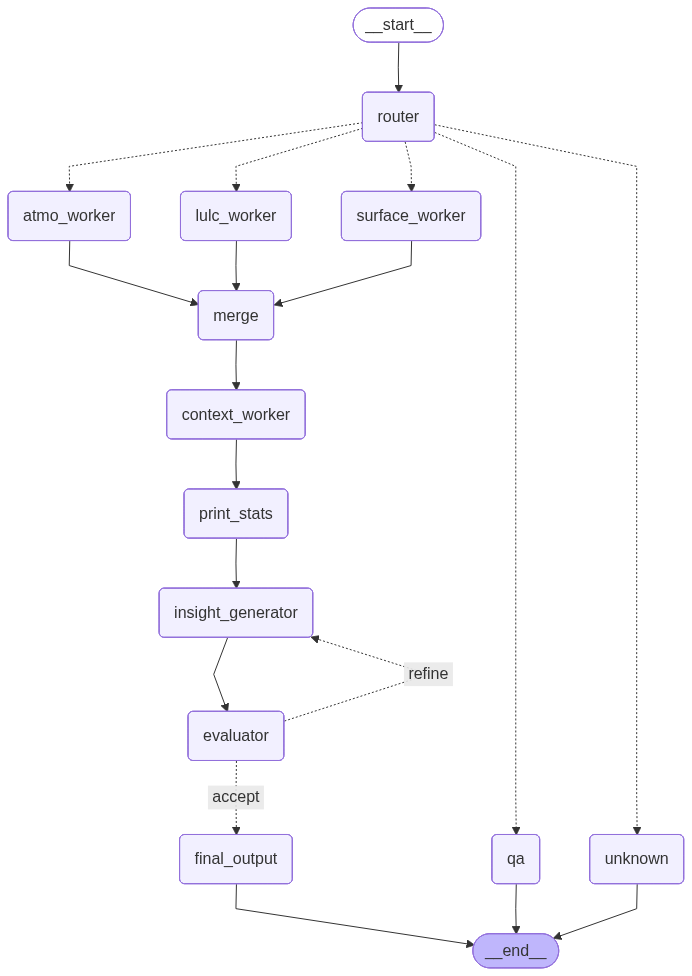

In [13]:
# =============================================================================
# CELL 4B — LangGraph Agent Graph
# Architecture: Router → [Surface Worker | Atmo Worker | QA Worker]
#               → Insight Generator → Evaluator → (Refiner loop) → END
# =============================================================================
from typing import Annotated, Literal, List, Optional
import operator
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel, Field

# ── LLM (Ollama) ──────────────────────────────────────────────────────────────
llm = ChatOllama(model=OLLAMA_MODEL, base_url="http://localhost:11434", temperature=0)
llm_with_tools = llm.bind_tools(ALL_TOOLS)

# ── State ─────────────────────────────────────────────────────────────────────
class AgentState(TypedDict):
    # Input
    user_input      : str
    # Parsed intent
    region          : Optional[str]
    start_date      : Optional[str]
    end_date        : Optional[str]
    variables       : List[str]
    intent          : str                    # "analysis" | "question" | "unknown"
    # Worker results (accumulated with operator.add)
    surface_stats   : dict
    atmo_stats      : dict
    web_context     : str
    # Insight + evaluation
    insight         : str
    eval_score      : int                    # 1-10
    eval_feedback   : str
    refine_count    : int
    # Final
    final_response  : str
    messages        : Annotated[list, operator.add]

# ── Pydantic schemas for structured outputs ───────────────────────────────────
class ParsedRequest(BaseModel):
    intent     : Literal["analysis", "question", "unknown"]
    region     : Optional[str]        = None
    start_date : Optional[str]        = None
    end_date   : Optional[str]        = None
    variables  : List[str]            = Field(default_factory=list)
    response   : str                  = ""

class InsightEval(BaseModel):
    score    : int   = Field(ge=1, le=10, description="Quality score 1-10")
    feedback : str   = Field(description="Specific feedback for improvement if score < 7")
    accept   : bool  = Field(description="True if score >= 7 and insight is acceptable")

# ── NODE 1: Router — always use raw JSON fallback for gemma3 ─────────────────
def node_router(state: AgentState) -> dict:
    """Parse user intent using raw JSON (reliable for gemma3:4b)."""
    print("\n[ROUTER] Parsing user request...")
    resp = requests.post(OLLAMA_URL,
        json={"model": OLLAMA_MODEL,
              "messages": [
                  {"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user",   "content": state["user_input"]}],
              "stream": False}, timeout=60)
    data = resp.json()
    raw  = data.get("message", {}).get("content", "{}").strip()
    if "```" in raw:
        raw = raw.split("```")[1]
        if raw.startswith("json"): raw = raw[4:]
    start = raw.find("{"); end = raw.rfind("}") + 1
    if start >= 0 and end > start: raw = raw[start:end]
    try:
        parsed = json.loads(raw)
    except Exception as e:
        print(f"  JSON parse failed: {e}")
        parsed = {"intent": "unknown", "region": None, "start_date": None,
                  "end_date": None, "variables": [], "response": ""}

    # Normalize variables
    vars_out = parsed.get("variables") or []
    if "all_surface" in vars_out:
        vars_out = list(SURFACE_INDEX_MAP.keys()) + ["lst", "uhi"]
    if "all_atmo" in vars_out:
        vars_out = list(ATMO_INDEX_MAP.keys())
    normalized = []
    for v in vars_out:
        vl = v.lower().strip()
        normalized.append(KEYWORD_MAP.get(vl, vl))
    vars_out = list(dict.fromkeys(normalized))

    print(f"  Intent: {parsed.get('intent')} | Region: {parsed.get('region')} | Vars: {vars_out}")
    return {
        "intent"    : parsed.get("intent", "unknown"),
        "region"    : parsed.get("region"),
        "start_date": parsed.get("start_date"),
        "end_date"  : parsed.get("end_date"),
        "variables" : vars_out,
        "messages"  : [AIMessage(content=parsed.get("response", ""))],
    }

# ── Routing edge — smart branching ───────────────────────────────────────────
def edge_route(state: AgentState) -> list:
    """Return list of next nodes based on what variables were requested."""
    intent = state["intent"]

    if intent == "qa":
        return ["qa"]
    if intent == "unknown":
        return ["unknown"]

    # For analysis: check which worker(s) are needed
    surface_keys = list(SURFACE_INDEX_MAP.keys()) + ["lst", "uhi", "rgb"]
    atmo_keys    = list(ATMO_INDEX_MAP.keys()) + ["ffpi"]
    vars_        = state.get("variables", [])

    needs_surface = any(v in surface_keys for v in vars_)
    needs_atmo    = any(v in atmo_keys    for v in vars_)
    needs_lulc    = "lulc" in vars_

    routes = []
    if needs_surface: routes.append("surface_worker")
    if needs_atmo:    routes.append("atmo_worker")
    if needs_lulc:    routes.append("lulc_worker")
    if not routes:    routes.append("unknown")
    return routes

# ── NODE 2a: Surface Worker ───────────────────────────────────────────────────
def node_surface_worker(state: AgentState) -> dict:
    """Run Landsat 8 surface index analysis."""
    # Guard: skip if router didn't extract required fields
    if not state.get("region") or not state.get("start_date") or not state.get("end_date"):
        print("\n[SURFACE WORKER] Skipped — missing region or dates")
        return {"surface_stats": {}}

    surface_vars = [v for v in state["variables"]
                    if v in list(SURFACE_INDEX_MAP.keys()) + ["lst","uhi","rgb"]]
    if not surface_vars:
        return {"surface_stats": {}}

    print(f"\n[SURFACE WORKER] Running: {surface_vars}")
    result = tool_surface_analysis.invoke({
        "region_name": state["region"],
        "start_date" : state["start_date"],
        "end_date"   : state["end_date"],
        "variables"  : surface_vars,
    })
    stats = result.get("stats", {})
    # For LULC: stats may be empty if compute_lulc ran standalone (plots already saved)
    # Re-check if lulc was requested and add placeholder so pipeline continues
    if "lulc" in surface_vars and not stats:
        stats["LULC_STATUS"] = {"classes": {}, "total_ha": 0, "note": "See saved map in outputs folder"}
    print(f"  ✓ Surface done: {list(stats.keys())}")
    return {"surface_stats": stats}

# ── NODE 2b: Atmospheric Worker ───────────────────────────────────────────────
def node_atmo_worker(state: AgentState) -> dict:
    """Run Sentinel-5P atmospheric analysis."""
    # Guard: skip if router didn't extract required fields
    if not state.get("region") or not state.get("start_date") or not state.get("end_date"):
        print("\n[ATMO WORKER] Skipped — missing region or dates")
        return {"atmo_stats": {}}

    atmo_vars = [v for v in state["variables"]
                 if v in list(ATMO_INDEX_MAP.keys()) + ["ffpi"]]
    if not atmo_vars:
        return {"atmo_stats": {}}

    print(f"\n[ATMO WORKER] Running: {atmo_vars}")
    result = tool_atmo_analysis.invoke({
        "region_name": state["region"],
        "start_date" : state["start_date"],
        "end_date"   : state["end_date"],
        "variables"  : atmo_vars,
    })
    stats = result.get("stats", {})
    print(f"  ✓ Atmo done: {list(stats.keys())}")
    return {"atmo_stats": stats}

# ── NODE 2c: LULC Worker ─────────────────────────────────────────────────────
def node_lulc_worker(state: AgentState) -> dict:
    """Run dedicated Land Cover Classification worker."""
    if not state.get("region") or not state.get("start_date") or not state.get("end_date"):
        print("\n[LULC WORKER] Skipped — missing region or dates")
        return {"surface_stats": {}}

    if "lulc" not in [v.lower() for v in state.get("variables", [])]:
        return {"surface_stats": {}}

    print(f"\n[LULC WORKER] Running land cover classification for {state['region']}...")
    result = tool_lulc_analysis.invoke({
        "region_name": state["region"],
        "start_date" : state["start_date"],
        "end_date"   : state["end_date"],
        "variables"  : state["variables"],
    })
    stats = result.get("stats", {})
    msg   = result.get("message", "")
    if result.get("success"):
        print(f"  ✓ LULC done: {msg}")
    else:
        print(f"  ✗ LULC failed: {msg}")
    return {"surface_stats": stats}

# ── NODE 2d: Web Context Worker ───────────────────────────────────────────────
def node_context_worker(state: AgentState) -> dict:
    """Fetch web context for the region and variables."""
    # Guard: skip if missing required fields
    if not state.get("region") or not state.get("start_date") or not state.get("end_date"):
        print("\n[CONTEXT WORKER] Skipped — missing region or dates")
        return {"web_context": ""}

    print(f"\n[CONTEXT WORKER] Fetching web context for {state['region']}...")
    result = tool_fetch_context.invoke({
        "region_name": state["region"],
        "start_date" : state["start_date"],
        "end_date"   : state["end_date"],
        "variables"  : state["variables"],
    })
    ctx = result.get("web_context", "")
    print(f"  ✓ Context: {result['message']}")
    return {"web_context": ctx}

# ── NODE 3: Stats Printer ─────────────────────────────────────────────────────
def node_print_stats(state: AgentState) -> dict:
    """Print statistics summary to console."""
    all_stats = {**state.get("surface_stats", {}), **state.get("atmo_stats", {})}
    if not all_stats:
        return {}
    sep  = "=" * 60
    dash = "-" * 45
    print(f"\n{sep}")
    print(f"  STATISTICS SUMMARY — {state['region']}")
    print(f"  Period: {state['start_date']} to {state['end_date']}")
    print(f"  {dash}")
    for var, s in all_stats.items():
        if isinstance(s, dict) and s.get("mean") is not None:
            print(f"  {var:<12} mean={s.get('mean',0):.4f}  "
                  f"median={s.get('median',0) or 0:.4f}  std={s.get('std',0) or 0:.4f}")
            print(f"  {'':12} min={s.get('min',0):.4f}   max={s.get('max',0):.4f}")
            print(f"  {'':12} p10={s.get('p10',0) or 0:.4f}   p90={s.get('p90',0) or 0:.4f}")
            monthly = s.get("monthly", {})
            if monthly:
                print(f"  {'':12} Monthly mean:")
                line = ""
                for m, v in sorted(monthly.items()):
                    entry = f"{m}:{v:.3f}  "
                    if len(line) + len(entry) > 52:
                        print(f"  {'':12}   {line.strip()}")
                        line = entry
                    else:
                        line += entry
                if line.strip():
                    print(f"  {'':12}   {line.strip()}")
        elif isinstance(s, dict) and "lst_mean" in s:
            print(f"  {'UHI':<12} LST mean={s['lst_mean']:.2f}°C  std={s['lst_std']:.2f}°C")
        elif isinstance(s, dict) and "classes" in s:
            # LULC stats
            total_ha = s.get('total_ha', 0)
            n_cls    = s.get('n_classes', 0)
            print(f"  {'LULC':<12} {n_cls} classes | Total: {total_ha:,.0f} ha")
            for cls_name, cls_data in s.get('classes', {}).items():
                ha  = cls_data.get('hectares', 0)
                pct = cls_data.get('percentage', 0)
                print(f"  {'':12}   {cls_name:<16} {ha:>10,.1f} ha  ({pct:.1f}%)")
    print(f"  {dash}")
    return {}

# ── NODE 4: Insight Generator ─────────────────────────────────────────────────
def node_insight_generator(state: AgentState) -> dict:
    """Generate scientific insight from stats + web context."""
    all_stats = {**state.get("surface_stats", {}), **state.get("atmo_stats", {})}
    feedback  = state.get("eval_feedback", "")
    count     = state.get("refine_count", 0)

    print(f"\n[INSIGHT GENERATOR] Generating insight (attempt {count+1})...")

    # Build stats text
    stats_lines = []
    UNIT_LOOKUP_LOCAL = {
        "NDVI":"index (-1 to 1)", "EVI":"index (-1 to 1)", "SAVI":"index (-1 to 1)",
        "NDWI":"index (-1 to 1)", "MNDWI":"index (-1 to 1)", "NDBI":"index (-1 to 1)",
        "UI":"index (-1 to 1)", "BSI":"index (-1 to 1)", "NDSI":"index (-1 to 1)",
        "NBI":"index (0 to 0.5)", "LST":"degrees Celsius",
        "CO":"mol/m2", "NO2":"mol/m2", "SO2":"mol/m2",
        "CH4":"ppb", "O3":"Dobson Units (DU)", "Aerosol":"unitless AAI",
        "GPP":"kgC/m2/8-day", "Burned Area":"Day of Year 1-366",
        "FFPI":"normalized 0-1",
    }
    for var, s in all_stats.items():
        unit = next((v for k,v in UNIT_LOOKUP_LOCAL.items()
                     if k.upper() in var.upper()), "dimensionless")
        if isinstance(s, dict) and s.get("mean") is not None:
            line = (f"  - {var} [{unit}]: mean={s['mean']:.6f}, "
                    f"min={s.get('min',0):.6f}, max={s.get('max',0):.6f}")
            for k in ["std","median","p10","p90"]:
                if s.get(k) is not None: line += f", {k}={s[k]:.6f}"
            stats_lines.append(line)
            monthly = s.get("monthly", {})
            if monthly:
                mstr = ", ".join(f"{m}:{v:.4f}" for m,v in sorted(monthly.items()))
                stats_lines.append(f"    Monthly: {mstr}")
        elif isinstance(s, dict) and "lst_mean" in s:
            stats_lines.append(f"  - UHI: LST mean={s['lst_mean']:.2f}°C std={s['lst_std']:.2f}°C")
        elif isinstance(s, dict) and "classes" in s:
            # LULC: format class breakdown for LLM
            total_ha = s.get('total_ha', 0)
            cls_lines = []
            for cls_name, cls_data in s.get('classes', {}).items():
                ha  = cls_data.get('hectares', 0)
                pct = cls_data.get('percentage', 0)
                cls_lines.append(f"{cls_name}: {ha:,.0f} ha ({pct:.1f}%)")
            stats_lines.append(
                f"  - LULC [area in hectares and %]: total={total_ha:,.0f} ha | "
                + " | ".join(cls_lines)
            )

    web_ctx  = state.get("web_context", "")
    web_sect = (f"\nReal-world context from web search:\n{web_ctx}\n" if web_ctx else "")
    feedback_sect = (f"\nPREVIOUS FEEDBACK TO ADDRESS:\n{feedback}\n" if feedback else "")

    prompt = (
        "You are an expert remote sensing and geospatial scientist writing a scientific briefing.\n"
        "RULES:\n"
        "- Use exact units shown in brackets. Never say \"ppm\".\n"
        "- p10 = 10% of pixels are BELOW this value (degraded areas).\n"
        "- p90 = 90% of pixels are BELOW this value (only top 10% exceed it).\n"
        "- Use monthly data to identify seasonal patterns, peaks, dips.\n"
        "- For LULC: discuss EACH class by exact name, hectares, and percentage. Do NOT use p10/p90/std for LULC — those are irrelevant. Focus on: dominant class, surprising absences, urban vs natural balance, implications for environment and planning.\n"
        "- Name specific districts, landmarks, rivers when relevant.\n"
        "- Only cite web context directly relevant to this region.\n"
        + feedback_sect + web_sect
        + f"\nRegion  : {state['region']}"
        f"\nPeriod  : {state['start_date']} to {state['end_date']}"
        f"\nVars    : {', '.join(state['variables'])}"
        f"\n\nSatellite statistics:\n{''.join(stats_lines)}"
        "\n\nWrite a scientific insight (7-10 sentences) covering:\n"
        "1. Annual mean interpretation\n"
        "2. Seasonal pattern from monthly data\n"
        "3. Spatial variability (p10/p90/std)\n"
        "4. Specific geographic features driving patterns\n"
        "5. Connection to real-world events (web context)\n"
        "6. Socioeconomic/physical drivers\n"
        "7. One notable anomaly\n"
        "8. Concrete actionable recommendation\n"
        "\nWrite in flowing paragraphs, not bullet points."
    )

    resp = requests.post(
        OLLAMA_URL,
        json={"model": OLLAMA_MODEL,
              "messages": [{"role": "user", "content": prompt}],
              "stream": False},
        timeout=180
    )
    insight = resp.json()["message"]["content"].strip()
    print(f"  ✓ Insight generated ({len(insight)} chars)")
    return {
        "insight"      : insight,
        "refine_count" : count + 1,
    }

# ── NODE 5: Evaluator ─────────────────────────────────────────────────────────
def node_evaluator(state: AgentState) -> dict:
    """Evaluate insight quality using structured LLM output."""
    print(f"\n[EVALUATOR] Evaluating insight quality...")
    evaluator_llm = llm.with_structured_output(InsightEval)

    all_stats = {**state.get("surface_stats",{}), **state.get("atmo_stats",{})}
    stats_summary = {k: {"mean": v.get("mean"), "monthly": v.get("monthly",{})}
                     for k, v in all_stats.items() if isinstance(v, dict)}

    eval_prompt = (
        "You are a senior geospatial scientist evaluating a satellite analysis insight.\n\n"
        f"REGION: {state['region']} | PERIOD: {state['start_date']} to {state['end_date']}\n"
        f"VARIABLES: {', '.join(state['variables'])}\n\n"
        f"STATISTICS SUMMARY: {json.dumps(stats_summary, indent=2)[:2000]}\n\n"
        f"INSIGHT TO EVALUATE:\n{state['insight']}\n\n"
        "Score this insight 1-10 on:\n"
        "- Scientific accuracy (units correct, no hallucinated values)\n"
        "- Use of seasonal/monthly data\n"
        "- Correct interpretation of p10/p90\n"
        "- Specificity (named places, real events)\n"
        "- Actionability of recommendation\n"
        "Accept (score >= 7) or reject with specific feedback."
    )

    result = evaluator_llm.invoke(eval_prompt)
    print(f"  ✓ Eval score: {result.score}/10 | Accept: {result.accept}")
    if not result.accept:
        print(f"  ✗ Feedback: {result.feedback[:100]}...")
    return {
        "eval_score"   : result.score,
        "eval_feedback": result.feedback,
    }

# ── Routing edge: accept or refine ────────────────────────────────────────────
def edge_eval(state: AgentState) -> str:
    if state.get("eval_score", 0) >= 7 or state.get("refine_count", 0) >= 3:
        return "accept"
    return "refine"

# ── NODE 6: Final output printer ──────────────────────────────────────────────
def node_final_output(state: AgentState) -> dict:
    """Print final insight to console."""
    sep = "=" * 60
    print(f"\n{sep}")
    print(f"  AI INSIGHT  (score: {state.get('eval_score','?')}/10)")
    print(f"  Region: {state['region']} | {state['start_date']} → {state['end_date']}")
    print(sep)
    insight = state.get("insight", "No insight generated.")
    print()
    for line in insight.split("\n"):
        if line.strip():
            for wline in textwrap.wrap(line.strip(), width=56):
                print(f"  {wline}")
        else:
            print()
    print(f"\n{sep}\n")
    return {"final_response": insight}

# ── NODE 7: QA node ───────────────────────────────────────────────────────────
def node_qa(state: AgentState) -> dict:
    """Answer general questions about satellite remote sensing."""
    print("\n[QA] Answering question...")
    resp = requests.post(OLLAMA_URL,
        json={"model": OLLAMA_MODEL,
              "messages": [
                  {"role": "system", "content": "You are an expert in satellite remote sensing and GIS."},
                  {"role": "user",   "content": state["user_input"]}],
              "stream": False}, timeout=60)
    answer = resp.json()["message"]["content"].strip()
    print(f"  ✓ Answer generated")
    return {"final_response": answer,
            "messages": [AIMessage(content=answer)]}

# ── NODE 8: Unknown handler ───────────────────────────────────────────────────
def node_unknown(state: AgentState) -> dict:
    msg = "I need more information. Please specify: region, date range, and what to analyze (e.g. NDVI, NO2, LST)."
    return {"final_response": msg, "messages": [AIMessage(content=msg)]}

# ── Add a merge node (waits for both workers if both ran) ────────────────────
def node_merge(state: AgentState) -> dict:
    """Merge point after parallel workers complete."""
    s_stats = state.get("surface_stats", {})
    a_stats = state.get("atmo_stats", {})
    total   = len(s_stats) + len(a_stats)
    print(f"\n[MERGE] Workers done — {total} variables ready")
    return {}

# ── Build the graph ───────────────────────────────────────────────────────────
builder = StateGraph(AgentState)

builder.add_node("router",            node_router)
builder.add_node("surface_worker",    node_surface_worker)
builder.add_node("atmo_worker",       node_atmo_worker)
builder.add_node("lulc_worker",       node_lulc_worker)
builder.add_node("merge",             node_merge)
builder.add_node("context_worker",    node_context_worker)
builder.add_node("print_stats",       node_print_stats)
builder.add_node("insight_generator", node_insight_generator)
builder.add_node("evaluator",         node_evaluator)
builder.add_node("final_output",      node_final_output)
builder.add_node("qa",                node_qa)
builder.add_node("unknown",           node_unknown)

# START → ROUTER
builder.add_edge(START, "router")

# ROUTER → smart branch (can fan out to multiple nodes in parallel)
builder.add_conditional_edges(
    "router",
    edge_route,
    ["surface_worker", "atmo_worker", "lulc_worker", "qa", "unknown"]
)

# All workers → merge
builder.add_edge("surface_worker", "merge")
builder.add_edge("atmo_worker",    "merge")
builder.add_edge("lulc_worker",    "merge")

# merge → context → stats → insight → evaluator loop
builder.add_edge("merge",             "context_worker")
builder.add_edge("context_worker",    "print_stats")
builder.add_edge("print_stats",       "insight_generator")
builder.add_edge("insight_generator", "evaluator")

builder.add_conditional_edges("evaluator", edge_eval, {
    "accept": "final_output",
    "refine": "insight_generator",
})

builder.add_edge("final_output", END)
builder.add_edge("qa",           END)
builder.add_edge("unknown",      END)

satellite_graph = builder.compile()
print("✅ LangGraph satellite agent compiled!")

try:
    from IPython.display import display, Image as IPImage
    display(IPImage(satellite_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(satellite_graph.get_graph().draw_mermaid())


╔══════════════════════════════════════════════════════╗
║  🛰️  SATELLITE ANALYSIS AI AGENT  (LangGraph)       ║
║  Router → Workers → Evaluator → Insight Loop        ║
╚══════════════════════════════════════════════════════╝
  Model   : gemma3:4b
  Outputs : /Users/rafiqnaufalkastara/Downloads/satellite_agent_outputs

  Examples:
  → Show NDVI in Jakarta from 2023-01-01 to 2023-12-31
  → Analyze NO2 and CO pollution in Beijing in 2022
  → LST and UHI in Cairo, summer 2021
  → What does NDVI measure?
  → Type "exit" to quit
────────────────────────────────────────────────────────

🤖 Agent running...

[ROUTER] Parsing user request...
  Intent: analysis | Region: Beijing | Vars: ['no2', 'co']

[ATMO WORKER] Running: ['no2', 'co']
  Resolving region: "Beijing"...
  Found in GAUL Level 1 (province/state)
  Done: NO2 (mol/m2)
  Done: CO (mol/m2)


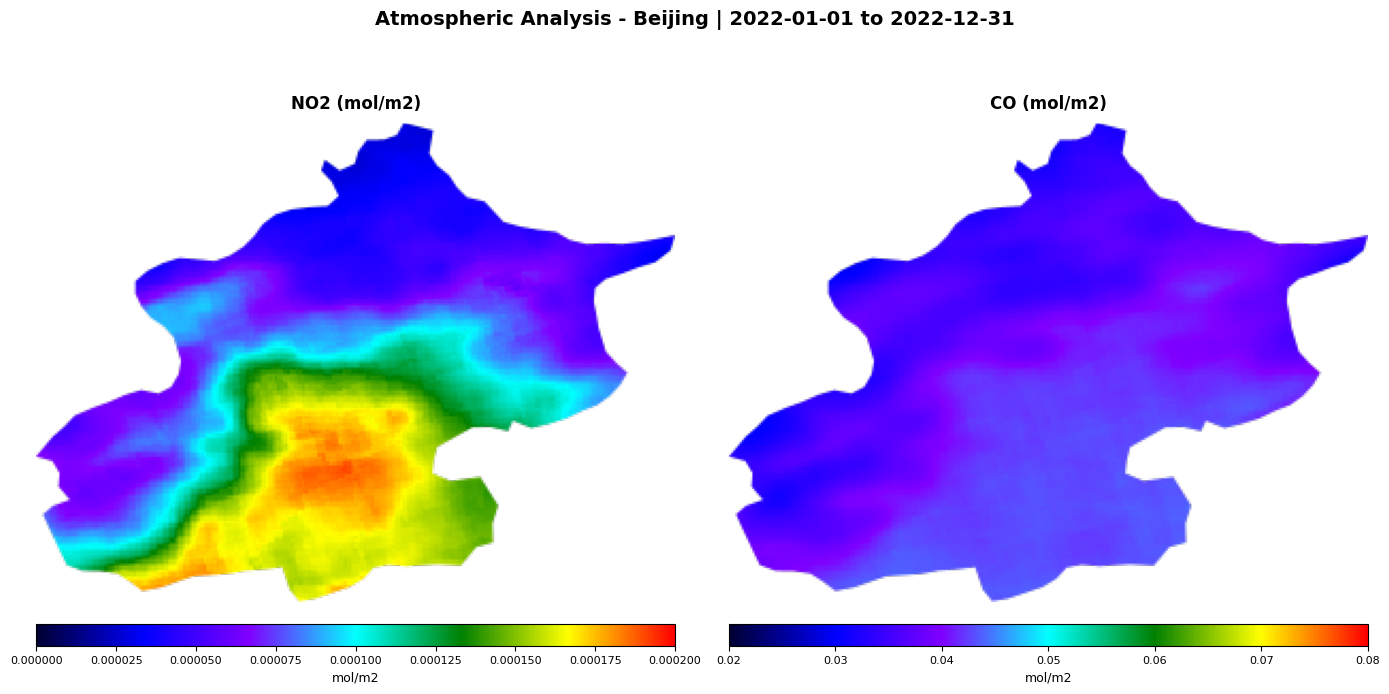

  Saved: /Users/rafiqnaufalkastara/Downloads/satellite_agent_outputs/Atmospheric_Analysis_-_Beijing_|_2022-01.jpg
  ✓ Atmo done: ['NO2', 'CO']

[MERGE] Workers done — 2 variables ready

[CONTEXT WORKER] Fetching web context for Beijing...
  [NO2] "Beijing nitrogen dioxide NO2 air quality 2022"
    ✓ Accepted (match:"beijing")
  [CO] "Beijing carbon monoxide air pollution 2022"
    ✓ Accepted (match:"beijing")
  [NEWS] "Beijing environment 2022"
    ✓ Accepted (match:"beijing")
  [NEWS] "Beijing climate pollution 2022"
    Skip (no-match): "How will climate change reshape Winter Olympics? List o"
    Skip (no-match): "Britain has pledged billions to tackle climate change –"
    ✓ Accepted (match:"beijing")
  [NEWS] "Beijing satellite monitoring 2022"
    ✓ Accepted (match:"china")

  Web context: 5 snippets retrieved
  ✓ Context: 5 snippets retrieved

  STATISTICS SUMMARY — Beijing
  Period: 2022-01-01 to 2022-12-31
  ---------------------------------------------
  NO2          mean=0.0

In [19]:
# =============================================================================
# CELL 5 — 🤖 LangGraph Satellite Agent Chat Loop
# =============================================================================
VAR_DESCRIPTIONS = {
    "ndvi":"NDVI","evi":"EVI","savi":"SAVI","ndwi":"NDWI","mndwi":"MNDWI",
    "ndbi":"NDBI","ui":"UI","nbi":"NBI","bsi":"BSI","ndsi":"NDSI",
    "lst":"LST","uhi":"UHI","rgb":"True Color",
    "co":"CO","ch4":"CH4","no2":"NO2","so2":"SO2","aerosol":"Aerosol",
    "o3":"O3","gpp":"GPP","burned":"Burned Area","ffpi":"FFPI",
    "lulc":"Land Cover Classification (LULC)",
}
MONTHS = {"01":"Jan","02":"Feb","03":"Mar","04":"Apr","05":"May","06":"Jun",
          "07":"Jul","08":"Aug","09":"Sep","10":"Oct","11":"Nov","12":"Dec"}

def fmt_vars(variables):
    return ", ".join(VAR_DESCRIPTIONS.get(v.lower(), v.upper()) for v in variables)

def fmt_date(start, end):
    sy,sm = start[:4],start[5:7]
    ey,em = end[:4],  end[5:7]
    if sy == ey: return f"{sy} ({MONTHS.get(sm,sm)}–{MONTHS.get(em,em)})"
    return f"{MONTHS.get(sm,sm)} {sy} – {MONTHS.get(em,em)} {ey}"

print("╔══════════════════════════════════════════════════════╗")
print("║  🛰️  SATELLITE ANALYSIS AI AGENT  (LangGraph)       ║")
print("║  Router → Workers → Evaluator → Insight Loop        ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"  Model   : {OLLAMA_MODEL}")
print(f"  Outputs : {OUTPUT_DIR}")
print()
print("  Examples:")
print("  → Show NDVI in Jakarta from 2023-01-01 to 2023-12-31")
print("  → Analyze NO2 and CO pollution in Beijing in 2022")
print("  → LST and UHI in Cairo, summer 2021")
print("  → What does NDVI measure?")
print("  → Type \"exit\" to quit")
print("─" * 56)

while True:
    try:
        user_input = input("\nYou: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\n👋 Stopped.")
        break

    if not user_input:
        continue
    if user_input.lower() in ["exit","quit","bye","stop"]:
        print(f"👋 Goodbye! Outputs saved to: {OUTPUT_DIR}")
        break

    # ── Run the graph ─────────────────────────────────────────────────────────
    print("\n🤖 Agent running...")
    try:
        init_state = {
            "user_input"   : user_input,
            "region"       : None,
            "start_date"   : None,
            "end_date"     : None,
            "variables"    : [],
            "intent"       : "unknown",
            "surface_stats": {},
            "atmo_stats"   : {},
            "web_context"  : "",
            "insight"      : "",
            "eval_score"   : 0,
            "eval_feedback": "",
            "refine_count" : 0,
            "final_response": "",
            "messages"     : [HumanMessage(content=user_input)],
        }

        result = satellite_graph.invoke(init_state)

        # Print summary for analysis intent
        if result.get("intent") == "analysis":
            vars_str  = fmt_vars(result.get("variables", []))
            date_str  = fmt_date(result["start_date"], result["end_date"])
            print(f"\n🤖 Analyzing {vars_str} in {result['region']} ({date_str})")
            print(f"   Eval score: {result.get('eval_score','?')}/10 | "
                  f"Refinements: {result.get('refine_count',0)-1}")
        elif result.get("intent") == "question":
            print(f"\n🤖 {result.get('final_response','')}")

    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

    print("─" * 56)
